In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
#%% Imports
import os
import re
import time
import math
import sys
import random
from pathlib import Path
from typing import List, Tuple, Optional

import numpy as np
import pandas as pd
from PIL import Image

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW

from sklearn.neighbors import NearestNeighbors
from sklearn.model_selection import train_test_split

# HuggingFace CLIP
from transformers import CLIPProcessor, CLIPModel

2025-10-11 15:49:12.275570: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1760197752.299685     222 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1760197752.306743     222 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [2]:
import subprocess
# Try to import open_clip (preferred). If missing, attempt to install.
try:
    import open_clip
except Exception:
    # Attempt to install open-clip (two common package sources)
    try:
        subprocess.check_call(
            [sys.executable, "-m", "pip", "install", "-q", "git+https://github.com/mlfoundations/open_clip.git"]
        )
    except Exception:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "open-clip-torch"])
    import open_clip

/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2225: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2225: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` 

✅ Using OpenCLIP backend (MLFoundations)


In [3]:
# Use the provided utils if available for downloading images
# Kaggle dataset path: /kaggle/input/dataset/utils.py
try:
    import sys
    sys.path.append('/kaggle/input/dataset')
    from utils import download_images
    print("Loaded provided download_images from dataset/utils.py")
except Exception as e:
    print("Could not import provided download_images; will use fallback downloader.", e)
    download_images = None

Loaded provided download_images from dataset/utils.py


In [4]:
#%% Config
DATA_ROOT = Path('/kaggle/input/dataset')
TRAIN_CSV = DATA_ROOT / 'train.csv'
TEST_CSV = DATA_ROOT / 'test.csv'
SAMPLE_OUT = DATA_ROOT / 'sample_test_out.csv'

WORK_DIR = Path('/kaggle/working')
IMAGES_DIR = WORK_DIR / 'images'
IMAGES_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# OpenCLIP model choice
OPENCLIP_MODEL = 'ViT-B-32'
OPENCLIP_PRETRAINED = 'laion2b_s34b_b79k'  # reliable LAION weights

BATCH_SIZE = 64
EMBED_DIM = 512  # CLIP base embed dim for vit-base
EPOCHS = 4
LR = 1e-4
SEED = 42

In [5]:
# Reproducibility
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


In [6]:
#%% Utility functions

def clean_text(text: str) -> str:
    """Basic text cleaning for catalog_content"""
    if not isinstance(text, str):
        return ""
    # Remove multiple spaces and weird characters
    text = text.replace('\n', ' ').replace('\r', ' ')
    text = re.sub(r'\s+', ' ', text).strip()
    return text

In [7]:
def extract_ipq(text: str) -> Optional[float]:
    """Try to extract an Item Pack Quantity (IPQ) or quantity mention from the catalog text.
    Returns a numeric quantity if found else None.
    Examples: "Pack of 3", "2 count", "500 g", "10 pack"
    """
    if not isinstance(text, str):
        return None
    t = text.lower()
    # look for patterns like 'pack of 3', '3 pack', 'x 3', 'count 3'
    m = re.search(r'pack of\s*(\d+)', t)
    if not m:
        m = re.search(r'(\d+)\s*pack(s)?', t)
    if not m:
        m = re.search(r'(\d+)\s*count', t)
    if m:
        try:
            return float(m.group(1))
        except:
            return None
    # grams / ml multipliers (optional): extract numeric followed by g/ml/kg/l
    m2 = re.search(r'(\d+[\.,]?\d*)\s*(g|kg|ml|l|litre|litres)', t)
    if m2:
        try:
            val = float(m2.group(1).replace(',', '.'))
            unit = m2.group(2)
            # convert to a simple scalar representing size
            if unit in ['kg']:
                val *= 1000
            if unit in ['l', 'litre', 'litres']:
                val *= 1000
            return float(val)
        except:
            return None
    return None
    
        

In [8]:
#%% Data loading
print('Loading CSVs...')
train = pd.read_csv(TRAIN_CSV)
test = pd.read_csv(TEST_CSV)
print(f'Train rows: {len(train)}, Test rows: {len(test)}')


Loading CSVs...
Train rows: 75000, Test rows: 75000


In [32]:
train

,sample_id,catalog_content,image_link,price
0,33127,"Item Name: La Victoria Green Taco Sauce Mild, ...",https://m.media-amazon.com/images/I/51mo8htwTH...,4.890
1,198967,"Item Name: Salerno Cookies, The Original Butte...",https://m.media-amazon.com/images/I/71YtriIHAA...,13.120
2,261251,"Item Name: Bear Creek Hearty Soup Bowl, Creamy...",https://m.media-amazon.com/images/I/51+PFEe-w-...,1.970
3,55858,Item Name: Judee’s Blue Cheese Powder 11.25 oz...,https://m.media-amazon.com/images/I/41mu0HAToD...,30.340
4,292686,"Item Name: kedem Sherry Cooking Wine, 12.7 Oun...",https://m.media-amazon.com/images/I/41sA037+Qv...,66.490
...,...,...,...,...
74995,41424,Item Name: ICE BREAKERS Spearmint Sugar Free M...,https://m.media-amazon.com/images/I/81p9PcPsff...,10.395
74996,35537,"Item Name: Davidson's Organics, Vanilla Essenc...",https://m.media-amazon.com/images/I/51DDKoa+mb...,35.920
74997,249971,Item Name: Jolly Rancher Hard Candy - Blue Ras...,https://m.media-amazon.com/images/I/91R2XCcpUf...,50.330
74998,188322,Item Name: Nescafe Dolce Gusto Capsules - CARA...,https://m.media-amazon.com/images/I/51W40YU98+...,15.275


In [9]:
# quick sanity: ensure sample_id present
assert 'sample_id' in train.columns

# Basic preprocessing
for df in [train, test]:
    df['catalog_content'] = df['catalog_content'].fillna('').map(clean_text)
    df['ipq'] = df['catalog_content'].map(extract_ipq)

# Fill ipq with 1.0 where missing (safe default)
train['ipq'] = train['ipq'].fillna(1.0)
test['ipq'] = test['ipq'].fillna(1.0)

In [10]:
df

,sample_id,catalog_content,image_link,ipq
0,100179,Item Name: Rani 14-Spice Eshamaya's Mango Chut...,https://m.media-amazon.com/images/I/71hoAn78AW...,300.0
1,245611,Item Name: Natural MILK TEA Flavoring extract ...,https://m.media-amazon.com/images/I/61ex8NHCIj...,1.0
2,146263,Item Name: Honey Filled Hard Candy - Bulk Pack...,https://m.media-amazon.com/images/I/61KCM61J8e...,1.0
3,95658,Item Name: Vlasic Snack'mm's Kosher Dill 16 Oz...,https://m.media-amazon.com/images/I/51Ex6uOH7y...,2.0
4,36806,"Item Name: McCormick Culinary Vanilla Extract,...",https://m.media-amazon.com/images/I/71QYlrOMoS...,1.0
...,...,...,...,...
74995,93616,Item Name: Good Seasons Zezty Italian Salad Dr...,https://m.media-amazon.com/images/I/51e9H27lgv...,4.0
74996,249434,"Item Name: Colombina Swirled Love Tiger Pops, ...",https://m.media-amazon.com/images/I/61IpkExmVt...,1.0
74997,162217,"Item Name: Kerns, Guava Nectar, 11.5 Fl Oz Can...",https://m.media-amazon.com/images/I/A1NMggyCLz...,1.0
74998,230487,Item Name: NY SPICE SHOP Licorice Candy - 1 Po...,https://m.media-amazon.com/images/I/81P69kEP5q...,1.0


In [11]:
train['price']

0         4.890
1        13.120
2         1.970
3        30.340
4        66.490
          ...  
74995    10.395
74996    35.920
74997    50.330
74998    15.275
74999    28.240
Name: price, Length: 75000, dtype: float64

In [12]:
# target transform: price distribution can be skewed. We'll predict log(price+1) during training
train['target'] = np.log1p(train['price'].clip(lower=0.01))


In [13]:
train['target']

0        1.773256
1        2.647592
2        1.088562
3        3.444895
4        4.211979
           ...   
74995    2.433175
74996    3.608753
74997    3.938275
74998    2.789630
74999    3.375538
Name: target, Length: 75000, dtype: float64

In [14]:
# Train/validation split
train_df, val_df = train_test_split(train, test_size=0.1, random_state=SEED)
print(f"Train split: {len(train_df)}, Val split: {len(val_df)}")

Train split: 67500, Val split: 7500


In [15]:
# If dataset already has local image files, use them. Otherwise download from image_link.

def simple_image_downloader(urls: List[str], out_dir: Path, start_idx: int = 0):
    """Fallback image downloader (serial)"""
    import requests
    out_dir.mkdir(parents=True, exist_ok=True)
    saved = []
    for i, url in enumerate(urls, start=start_idx):
        fname = out_dir / f'{i}.jpg'
        try:
            r = requests.get(url, timeout=10)
            if r.status_code == 200:
                with open(fname, 'wb') as f:
                    f.write(r.content)
                saved.append(fname)
            else:
                saved.append(None)
        except Exception:
            saved.append(None)
    return saved

In [16]:
def build_image_index(df: pd.DataFrame, out_dir: Path, replace_existing: bool = False) -> dict:
    """Return a dict mapping sample_id -> local image path (or None) for rows in df."""
    mapping = {}
    # if provided download_images exists, use it
    if download_images is not None:
        print('Using provided download_images to fetch images (may retry).')
        # prepare list of (sample_id, url)
        items = list(zip(df['sample_id'].astype(str).tolist(), df['image_link'].astype(str).tolist()))
        # download_images should return mapping; adapt if necessary
        try:
            results = download_images(items, str(out_dir))
            # expected results: dict of sample_id -> local_path or ''/None
            for sid, url in items:
                local = results.get(sid, None)
                mapping[sid] = Path(local) if local else None
            return mapping
        except Exception as e:
            print('Provided download_images failed; falling back to simple downloader', e)

    # fallback: download serially
    urls = df['image_link'].fillna('').tolist()
    saved = simple_image_downloader(urls, out_dir)
    for sid, p in zip(df['sample_id'].astype(str).tolist(), saved):
        mapping[sid] = str(p) if p is not None else None
    return mapping

In [17]:
# For time reasons in notebook / competition runs, it's common to download only a subset or reuse cached images.
# We'll create separate image folders for train/val/test
train_img_dir = IMAGES_DIR / 'train'
val_img_dir = IMAGES_DIR / 'val'
test_img_dir = IMAGES_DIR / 'test'
train_img_dir.mkdir(parents=True, exist_ok=True)
val_img_dir.mkdir(parents=True, exist_ok=True)
test_img_dir.mkdir(parents=True, exist_ok=True)

In [18]:
# WARNING: full download may take long; optionally skip if images are not needed or use a cached subset.
# For completeness we show how to download for the splits (commented to avoid accidental long downloads in Kaggle preview)
# Uncomment the following lines to perform downloads.

# train_img_map = build_image_index(train_df, train_img_dir)
# val_img_map = build_image_index(val_df, val_img_dir)
# test_img_map = build_image_index(test, test_img_dir)

# For now, keep image maps empty and handle missing images in dataset by using CLIP default processing (black image)
train_img_map = {}
val_img_map = {}
test_img_map = {}

In [19]:
# Replace your old PricingDataset + collate_fn with this flexible version.

class PricingDataset(Dataset):
    def __init__(self,
                 df: pd.DataFrame,
                 image_map: dict,
                 processor: Optional[object] = None,   # HF processor or None
                 split: str = 'train'):
        """
        Returns for each sample:
          - sample_id
          - raw_image : PIL.Image
          - input_text : str
          - ipq : torch.tensor(float)
        Optionally (if processor provided):
          - image_inputs and text_inputs inside each sample (HF-format dicts)
        """
        self.df = df.reset_index(drop=True)
        self.image_map = image_map or {}
        self.processor = processor
        self.split = split

    def __len__(self):
        return len(self.df)

    def _load_image(self, sample_id: str, url: str):
        # Use local file if present
        local = self.image_map.get(str(sample_id))
        if local:
            try:
                return Image.open(local).convert('RGB')
            except Exception:
                pass
        # Try download (best-effort); else placeholder
        try:
            from io import BytesIO
            import requests
            resp = requests.get(url, timeout=6)
            return Image.open(BytesIO(resp.content)).convert('RGB')
        except Exception:
            return Image.new('RGB', (224, 224), (0, 0, 0))

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        sid = row['sample_id']
        text = row['catalog_content']
        ipq = float(row.get('ipq', 1.0))
        image = self._load_image(sid, row.get('image_link', ''))

        sample = {
            'sample_id': sid,
            'raw_image': image,         # PIL.Image for OpenCLIP pipeline
            'input_text': text,         # raw text for OpenCLIP pipeline
            'ipq': torch.tensor(ipq, dtype=torch.float32)
        }

        # If HF processor is provided, produce HF-style tensors as well
        if self.processor is not None:
            try:
                text_inputs = self.processor(text=[text], return_tensors='pt', padding=True, truncation=True)
                image_inputs = self.processor(images=image, return_tensors='pt')
                sample['text_inputs'] = text_inputs
                sample['image_inputs'] = image_inputs
            except Exception as e:
                # if processor fails, still return raw_image & input_text
                sample['text_inputs'] = None
                sample['image_inputs'] = None

        if self.split != 'test':
            sample['target'] = torch.tensor(float(row['target']), dtype=torch.float32)

        return sample


def collate_fn(batch):
    """
    Collate collects both raw_images+input_texts and (if present) HF-style processed tensors.
    Output keys:
      - sample_id (list)
      - raw_images (list[PIL.Image])
      - input_texts (list[str])
      - ipq (Tensor [B])
    Optional (only if dataset returned them):
      - pixel_values (Tensor [B,C,H,W])
      - input_ids (Tensor [B,seq])
      - attention_mask (Tensor [B,seq])
    - target (Tensor [B]) if present
    """
    sample_ids = [b['sample_id'] for b in batch]
    ipqs = torch.stack([b['ipq'] for b in batch])

    raw_images = [b['raw_image'] for b in batch]
    input_texts = [b['input_text'] for b in batch]

    out = {
        'sample_id': sample_ids,
        'raw_images': raw_images,
        'input_texts': input_texts,
        'ipq': ipqs
    }

    # If HF-style inputs exist and are not None, stack them
    if 'image_inputs' in batch[0] and batch[0]['image_inputs'] is not None:
        # Each b['image_inputs'] is a dict returned by HF processor: {'pixel_values': Tensor}
        pixel_values = torch.cat([b['image_inputs']['pixel_values'] for b in batch], dim=0)
        out['pixel_values'] = pixel_values

    if 'text_inputs' in batch[0] and batch[0]['text_inputs'] is not None:
        input_ids = torch.cat([b['text_inputs']['input_ids'] for b in batch], dim=0)
        attention_mask = torch.cat([b['text_inputs']['attention_mask'] for b in batch], dim=0)
        out['input_ids'] = input_ids
        out['attention_mask'] = attention_mask

    if 'target' in batch[0]:
        out['target'] = torch.stack([b['target'] for b in batch])

    return out


In [20]:
#%% Load OpenCLIP model + preprocess + tokenizer
print("Loading OpenCLIP model and transforms...")
model, _, preprocess = open_clip.create_model_and_transforms(OPENCLIP_MODEL, pretrained=OPENCLIP_PRETRAINED)
tokenizer = open_clip.get_tokenizer(OPENCLIP_MODEL)

model.to(DEVICE)
model.eval()
for p in model.parameters():
    p.requires_grad = False

print("OpenCLIP loaded:", OPENCLIP_MODEL, OPENCLIP_PRETRAINED)


Loading OpenCLIP model and transforms...
OpenCLIP loaded: ViT-B-32 laion2b_s34b_b79k


In [21]:
#%% Embedding extraction using open_clip
def extract_openclip_embeddings(dataloader: DataLoader, model, preprocess_fn, tokenizer_fn, device: torch.device):
    """
    Expects dataloader to yield dicts with keys 'raw_images' (list of PIL.Image)
    and 'input_texts' (list of str) and 'sample_id'.
    Returns: ids_list, image_embeddings_np, text_embeddings_np
    """
    img_embs = []
    txt_embs = []
    ids = []

    with torch.no_grad():
        for batch in dataloader:
            # preprocess images -> tensor batch
            raw_images = batch['raw_images']   # list of PIL.Image
            img_tensors = torch.stack([preprocess_fn(img) for img in raw_images], dim=0).to(device)

            # tokenize texts
            texts = batch['input_texts']
            text_tokens = tokenizer_fn(texts).to(device)

            image_features = model.encode_image(img_tensors)   # (B, D)
            text_features = model.encode_text(text_tokens)     # (B, D)

            # normalize
            image_features = image_features / image_features.norm(p=2, dim=-1, keepdim=True)
            text_features = text_features / text_features.norm(p=2, dim=-1, keepdim=True)

            img_embs.append(image_features.cpu().numpy())
            txt_embs.append(text_features.cpu().numpy())
            ids.extend(batch['sample_id'])

    img_embs = np.vstack(img_embs)
    txt_embs = np.vstack(txt_embs)
    return ids, img_embs, txt_embs

In [22]:
#%% Build small dataloaders for embedding extraction (use modest batch size)
train_dataset_small = PricingDataset(train_df, train_img_map, split='train')
val_dataset_small = PricingDataset(val_df, val_img_map, split='train')

In [21]:
train_loader_small = DataLoader(train_dataset_small, batch_size=32, shuffle=False, collate_fn=collate_fn)
val_loader_small = DataLoader(val_dataset_small, batch_size=32, shuffle=False, collate_fn=collate_fn)

print('Extracting OpenCLIP embeddings for train and val (will run inference on model - may be slow)')
train_ids, train_img_embs, train_txt_embs = extract_openclip_embeddings(train_loader_small, model, preprocess, tokenizer, DEVICE)
val_ids, val_img_embs, val_txt_embs = extract_openclip_embeddings(val_loader_small, model, preprocess, tokenizer, DEVICE)



Extracting OpenCLIP embeddings for train and val (will run inference on model - may be slow)


KeyboardInterrupt: 

In [23]:
import numpy as np, torch
from tqdm import tqdm

def safe_extract_openclip_embeddings(dataloader, model, preprocess_fn, tokenizer_fn, device, micro_batch_size=8):
    model.eval()
    ids_all, img_embs_list, txt_embs_list = [], [], []

    for batch in tqdm(dataloader, desc="DL batches"):
        sample_ids = batch['sample_id']
        raw_images = batch['raw_images']
        input_texts = batch['input_texts']
        n = len(raw_images)
        start = 0
        img_chunks, txt_chunks = [], []

        with torch.no_grad():
            while start < n:
                end = min(n, start + micro_batch_size)
                micro_imgs = raw_images[start:end]
                # preprocess on CPU
                img_tensors = torch.stack([preprocess_fn(im) for im in micro_imgs], dim=0).to(device)
                text_tokens = tokenizer_fn(input_texts[start:end]).to(device)

                image_features = model.encode_image(img_tensors)
                text_features = model.encode_text(text_tokens)

                image_features = image_features / (image_features.norm(p=2, dim=-1, keepdim=True) + 1e-10)
                text_features  = text_features  / (text_features.norm(p=2, dim=-1, keepdim=True) + 1e-10)

                img_chunks.append(image_features.cpu().numpy())
                txt_chunks.append(text_features.cpu().numpy())

                # free GPU memory quickly
                del img_tensors, text_tokens, image_features, text_features
                if torch.cuda.is_available():
                    torch.cuda.empty_cache()

                start = end

        ids_all.extend(sample_ids)
        img_embs_list.append(np.vstack(img_chunks))
        txt_embs_list.append(np.vstack(txt_chunks))

    img_embs = np.vstack(img_embs_list) if img_embs_list else np.zeros((0, 512))
    txt_embs = np.vstack(txt_embs_list) if txt_embs_list else np.zeros((0, 512))
    return ids_all, img_embs, txt_embs


In [24]:
SAFE_DL_BATCH = 8       # top-level dataloader batch (lower → safer)
NUM_WORKERS = 2         # 0 for simpler debugging
MICRO_BATCH = 4         # move 4 images per GPU forward pass

train_loader_small = DataLoader(train_dataset_small, batch_size=SAFE_DL_BATCH,
                                shuffle=False, collate_fn=collate_fn,
                                num_workers=NUM_WORKERS, pin_memory=True)
val_loader_small = DataLoader(val_dataset_small, batch_size=SAFE_DL_BATCH,
                              shuffle=False, collate_fn=collate_fn,
                              num_workers=NUM_WORKERS, pin_memory=True)

train_ids, train_img_embs, train_txt_embs = safe_extract_openclip_embeddings(
    train_loader_small, model, preprocess, tokenizer, DEVICE, micro_batch_size=MICRO_BATCH
)
val_ids, val_img_embs, val_txt_embs = safe_extract_openclip_embeddings(
    val_loader_small, model, preprocess, tokenizer, DEVICE, micro_batch_size=MICRO_BATCH
)


DL batches: 100%|██████████| 938/938 [10:48<00:00,  1.45it/s]


In [25]:
print("Train IDs:", len(train_ids)) 
print("Train img emb shape:", train_img_embs.shape) 
print("Train txt emb shape:", train_txt_embs.shape) 
print("Example embedding (first):", train_img_embs[0][:5])

Train IDs: 67500
Train img emb shape: (67500, 512)
Train txt emb shape: (67500, 512)
Example embedding (first): [ 0.00021931 -0.1877809  -0.09004832  0.1180388  -0.0174094 ]


In [27]:
#--- Combine extracted embeddings into DataFrames --- 
train_emb_df = pd.DataFrame({'sample_id': train_ids}) 
train_emb_df['img_emb'] = list(train_img_embs) 
train_emb_df['txt_emb'] = list(train_txt_embs) 
val_emb_df = pd.DataFrame({'sample_id': val_ids}) 
val_emb_df['img_emb'] = list(val_img_embs) 
val_emb_df['txt_emb'] = list(val_txt_embs) # Merge into original dataframes 
train_df = train_df.merge(train_emb_df, on='sample_id', how='left') 
val_df = val_df.merge(val_emb_df, on='sample_id', how='left') 
print("Merged embeddings back into train_df and val_df")

Merged embeddings back into train_df and val_df


In [29]:
#--- Combine extracted embeddings into DataFrames --- 
train_emb_df = pd.DataFrame({'sample_id': train_ids})
train_emb_df['img_emb'] = list(train_img_embs)
train_emb_df['txt_emb'] = list(train_txt_embs)

val_emb_df = pd.DataFrame({'sample_id': val_ids})
val_emb_df['img_emb'] = list(val_img_embs)
val_emb_df['txt_emb'] = list(val_txt_embs)

# Merge embeddings into original dataframes
train_df = train_df.merge(train_emb_df, on='sample_id', how='left')
val_df = val_df.merge(val_emb_df, on='sample_id', how='left')
print("✅ Merged embeddings back into train_df and val_df")

# ================== KNN ENHANCER FOR FEATURE SMOOTHING ==================

from sklearn.neighbors import NearestNeighbors
import numpy as np

class KNNEnhancer:
    """
    Enhances embeddings using nearest neighbors in image embedding space.
    Produces smoothed representations that reflect similar product contexts.
    """
    def __init__(self, k: int = 8):
        self.k = k
        self.knn_img = None
        self.img_embs = None

    def fit(self, img_embs: np.ndarray):
        self.img_embs = img_embs
        self.knn_img = NearestNeighbors(n_neighbors=self.k, metric='euclidean')
        self.knn_img.fit(img_embs)
        print(f"KNNEnhancer fitted on {len(img_embs)} samples with k={self.k}")

    def enhance(self, query_img_embs: np.ndarray) -> np.ndarray:
        dists, idxs = self.knn_img.kneighbors(query_img_embs)
        enhanced = []
        for ds, ids in zip(dists, idxs):
            weights = 1.0 / (ds + 1e-6)
            weights /= weights.sum()
            neighbor_embs = self.img_embs[ids]
            enhanced_emb = (neighbor_embs * weights[:, None]).sum(axis=0)
            enhanced.append(enhanced_emb)
        return np.vstack(enhanced)

# --- Define targets before fitting ---
train_targets = train_df['target'].values
val_targets = val_df['target'].values

# --- Fit the enhancer ---
knn = KNNEnhancer(k=8)
knn.fit(np.vstack(train_df['img_emb'].values))

# --- Apply KNN enhancement ---
train_enh = knn.enhance(np.vstack(train_df['img_emb'].values))
val_enh = knn.enhance(np.vstack(val_df['img_emb'].values))

# --- Combine features ---
train_features = np.hstack([
    np.vstack(train_df['img_emb'].values),
    np.vstack(train_df['txt_emb'].values),
    train_enh,
    train_df[['ipq']].values
])

val_features = np.hstack([
    np.vstack(val_df['img_emb'].values),
    np.vstack(val_df['txt_emb'].values),
    val_enh,
    val_df[['ipq']].values
])

print("✅ Feature shapes -- train:", train_features.shape, "val:", val_features.shape)


✅ Merged embeddings back into train_df and val_df


KeyError: 'img_emb'

In [30]:
# --- Combine extracted embeddings into DataFrames ---
train_emb_df = pd.DataFrame({
    'sample_id': train_ids,
    'img_emb': list(train_img_embs),
    'txt_emb': list(train_txt_embs)
}).astype({'sample_id': str})

val_emb_df = pd.DataFrame({
    'sample_id': val_ids,
    'img_emb': list(val_img_embs),
    'txt_emb': list(val_txt_embs)
}).astype({'sample_id': str})

# --- Ensure sample_id consistency in main DataFrames ---
train_df['sample_id'] = train_df['sample_id'].astype(str)
val_df['sample_id'] = val_df['sample_id'].astype(str)

# --- Merge embeddings ---
train_df = train_df.merge(train_emb_df, on='sample_id', how='left')
val_df = val_df.merge(val_emb_df, on='sample_id', how='left')

print("✅ Merged embeddings back into train_df and val_df")
print("🔍 Columns now available:", train_df.columns.tolist()[:10], "...")

# === Sanity check ===
if 'img_emb' not in train_df.columns:
    raise ValueError("❌ Merge failed — 'img_emb' column missing. Check sample_id alignment.")

#%% ================== KNN ENHANCER FOR FEATURE SMOOTHING ==================

from sklearn.neighbors import NearestNeighbors
import numpy as np

class KNNEnhancer:
    def __init__(self, k: int = 8):
        self.k = k
        self.knn_img = None
        self.img_embs = None

    def fit(self, img_embs: np.ndarray):
        self.img_embs = img_embs
        self.knn_img = NearestNeighbors(n_neighbors=self.k, metric='euclidean')
        self.knn_img.fit(img_embs)
        print(f"KNNEnhancer fitted on {len(img_embs)} samples with k={self.k}")

    def enhance(self, query_img_embs: np.ndarray) -> np.ndarray:
        dists, idxs = self.knn_img.kneighbors(query_img_embs)
        enhanced = []
        for ds, ids in zip(dists, idxs):
            weights = 1.0 / (ds + 1e-6)
            weights /= weights.sum()
            neighbor_embs = self.img_embs[ids]
            enhanced_emb = (neighbor_embs * weights[:, None]).sum(axis=0)
            enhanced.append(enhanced_emb)
        return np.vstack(enhanced)

# --- Define targets before fitting ---
train_targets = train_df['target'].values
val_targets = val_df['target'].values

# --- Extract embeddings as stacked numpy arrays ---
train_img_array = np.vstack(train_df['img_emb'].values)
train_txt_array = np.vstack(train_df['txt_emb'].values)
val_img_array = np.vstack(val_df['img_emb'].values)
val_txt_array = np.vstack(val_df['txt_emb'].values)

# --- Fit and apply KNN enhancement ---
knn = KNNEnhancer(k=8)
knn.fit(train_img_array)

train_enh = knn.enhance(train_img_array)
val_enh = knn.enhance(val_img_array)

# --- Combine final features ---
train_features = np.hstack([
    train_img_array,
    train_txt_array,
    train_enh,
    train_df[['ipq']].values
])

val_features = np.hstack([
    val_img_array,
    val_txt_array,
    val_enh,
    val_df[['ipq']].values
])

print("✅ Feature shapes -- train:", train_features.shape, "val:", val_features.shape)


✅ Merged embeddings back into train_df and val_df
🔍 Columns now available: ['sample_id', 'catalog_content', 'image_link', 'price', 'ipq', 'target', 'img_emb_x', 'txt_emb_x', 'img_emb_y', 'txt_emb_y'] ...
KNNEnhancer fitted on 67500 samples with k=8
✅ Feature shapes -- train: (67500, 1537) val: (7500, 1537)


In [31]:
#%% ================== IMPROVED MLP TRAINING FOR PRICE PREDICTION ==================

import torch
import torch.nn as nn
from torch.optim import AdamW
from torch.utils.data import Dataset, DataLoader
import numpy as np
from sklearn.preprocessing import StandardScaler

# ===== Normalize Features =====
scaler = StandardScaler()
train_features = scaler.fit_transform(train_features)
val_features = scaler.transform(val_features)

# ===== NumpyDataset =====
class NumpyDataset(Dataset):
    def __init__(self, X: np.ndarray, y: np.ndarray = None):
        self.X = X.astype(np.float32)
        self.y = y.astype(np.float32) if y is not None else None

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        if self.y is None:
            return {'x': torch.from_numpy(self.X[idx])}
        return {
            'x': torch.from_numpy(self.X[idx]),
            'y': torch.tensor(self.y[idx], dtype=torch.float32)
        }

# ===== Improved MLP Model =====
class PriceRegressor(nn.Module):
    def __init__(self, input_dim: int, hidden_dim: int = 1024):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.LayerNorm(hidden_dim // 2),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(hidden_dim // 2, 1)
        )

    def forward(self, x):
        return self.model(x).squeeze(-1)

# ===== Safer SMAPE Loss =====
def smape_loss_torch(y_true, y_pred):
    pred_price = torch.clamp(torch.expm1(y_pred), min=1e-3, max=1e6)
    true_price = torch.clamp(torch.expm1(y_true), min=1e-3, max=1e6)
    denom = (torch.abs(true_price) + torch.abs(pred_price)) / 2.0 + 1e-6
    loss = torch.mean(torch.abs(pred_price - true_price) / denom)
    return loss

# ===== Dataloaders =====
train_ds = NumpyDataset(train_features, train_targets)
val_ds = NumpyDataset(val_features, val_targets)
train_loader = DataLoader(train_ds, batch_size=128, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=256, shuffle=False)

# ===== Model, Optimizer, Scheduler =====
input_dim = train_features.shape[1]
model = PriceRegressor(input_dim=input_dim, hidden_dim=1024).to(DEVICE)
optimizer = AdamW(model.parameters(), lr=1e-4, weight_decay=1e-3)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50)

# ===== Training with Early Stopping =====
EPOCHS = 100
patience = 6
best_val = float('inf')
epochs_no_improve = 0

print(f"Training on {len(train_ds)} samples, validating on {len(val_ds)} samples...")

for epoch in range(EPOCHS):
    model.train()
    train_losses = []
    for batch in train_loader:
        x = batch['x'].to(DEVICE)
        y = batch['y'].to(DEVICE)
        optimizer.zero_grad()
        pred = model(x)
        loss = smape_loss_torch(y, pred)
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())

    avg_train = np.mean(train_losses)

    # ---- Validation ----
    model.eval()
    val_losses = []
    with torch.no_grad():
        for batch in val_loader:
            x = batch['x'].to(DEVICE)
            y = batch['y'].to(DEVICE)
            pred = model(x)
            loss = smape_loss_torch(y, pred)
            val_losses.append(loss.item())

    avg_val = np.mean(val_losses)
    scheduler.step()

    print(f"Epoch {epoch+1:03d}/{EPOCHS} | Train SMAPE: {avg_train:.5f} | Val SMAPE: {avg_val:.5f}")

    # ---- Early stopping ----
    if avg_val < best_val:
        best_val = avg_val
        torch.save({
            'model_state_dict': model.state_dict(),
            'scaler': scaler
        }, WORK_DIR / 'best_price_mlp_v2.pth')
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print(f"Early stopping triggered at epoch {epoch+1}")
            break

print(f"Training complete. Best Val SMAPE: {best_val:.5f}")


Training on 67500 samples, validating on 7500 samples...
Epoch 001/100 | Train SMAPE: 0.60535 | Val SMAPE: 0.55048
Epoch 002/100 | Train SMAPE: 0.52611 | Val SMAPE: 0.53212
Epoch 003/100 | Train SMAPE: 0.49808 | Val SMAPE: 0.51978
Epoch 004/100 | Train SMAPE: 0.47431 | Val SMAPE: 0.51755
Epoch 005/100 | Train SMAPE: 0.45578 | Val SMAPE: 0.50789
Epoch 006/100 | Train SMAPE: 0.43968 | Val SMAPE: 0.50552
Epoch 007/100 | Train SMAPE: 0.42612 | Val SMAPE: 0.50556
Epoch 008/100 | Train SMAPE: 0.41359 | Val SMAPE: 0.51001
Epoch 009/100 | Train SMAPE: 0.40139 | Val SMAPE: 0.50544
Epoch 010/100 | Train SMAPE: 0.39147 | Val SMAPE: 0.50805
Epoch 011/100 | Train SMAPE: 0.38207 | Val SMAPE: 0.50265
Epoch 012/100 | Train SMAPE: 0.37310 | Val SMAPE: 0.49923
Epoch 013/100 | Train SMAPE: 0.36607 | Val SMAPE: 0.49671
Epoch 014/100 | Train SMAPE: 0.35806 | Val SMAPE: 0.49666
Epoch 015/100 | Train SMAPE: 0.35149 | Val SMAPE: 0.49870
Epoch 016/100 | Train SMAPE: 0.34521 | Val SMAPE: 0.50350
Epoch 017/100 |

In [32]:
#%% ================== TEST SET INFERENCE PIPELINE ==================

import pandas as pd
import torch
import numpy as np

# --- Load the best model and scaler ---
checkpoint = torch.load(WORK_DIR / 'best_price_mlp_v2.pth', map_location=DEVICE)
model.load_state_dict(checkpoint['model_state_dict'])
scaler = checkpoint['scaler']
model.eval()

print("✅ Loaded best model for inference.")

# --- Extract embeddings for test set (same as train/val) ---
test_emb_df = pd.DataFrame({
    'sample_id': test_ids,
    'img_emb': list(test_img_embs),
    'txt_emb': list(test_txt_embs)
}).astype({'sample_id': str})

test['sample_id'] = test['sample_id'].astype(str)
test = test.merge(test_emb_df, on='sample_id', how='left')
print("✅ Merged embeddings into test set")

# --- Apply KNN enhancement using the fitted KNN from training ---
test_img_array = np.vstack(test['img_emb'].values)
test_txt_array = np.vstack(test['txt_emb'].values)
test_enh = knn.enhance(test_img_array)

# --- Combine features in same order as train ---
test_features = np.hstack([
    test_img_array,
    test_txt_array,
    test_enh,
    test[['ipq']].values
])

# --- Normalize using same scaler as training ---
test_features = scaler.transform(test_features)

# --- Run model predictions ---
preds = []
with torch.no_grad():
    bs = 512  # batch size for inference
    for i in range(0, len(test_features), bs):
        x = torch.from_numpy(test_features[i:i+bs]).to(DEVICE)
        pred_log = model(x)
        pred_price = torch.expm1(pred_log).cpu().numpy()  # convert log(price+1) back
        preds.extend(pred_price)

# --- Format predictions ---
preds = np.clip(preds, a_min=0.01, a_max=None)
submission = pd.DataFrame({
    'sample_id': test['sample_id'],
    'price': preds
})

# --- Save final output ---
submission.to_csv(WORK_DIR / 'sample_test_out.csv', index=False)
print("✅ Saved final predictions to:", WORK_DIR / 'sample_test_out.csv')




UnpicklingError: Weights only load failed. This file can still be loaded, to do so you have two options, [1mdo those steps only if you trust the source of the checkpoint[0m. 
	(1) In PyTorch 2.6, we changed the default value of the `weights_only` argument in `torch.load` from `False` to `True`. Re-running `torch.load` with `weights_only` set to `False` will likely succeed, but it can result in arbitrary code execution. Do it only if you got the file from a trusted source.
	(2) Alternatively, to load with `weights_only=True` please check the recommended steps in the following error message.
	WeightsUnpickler error: Unsupported global: GLOBAL sklearn.preprocessing._data.StandardScaler was not an allowed global by default. Please use `torch.serialization.add_safe_globals([StandardScaler])` or the `torch.serialization.safe_globals([StandardScaler])` context manager to allowlist this global if you trust this class/function.

Check the documentation of torch.load to learn more about types 

In [39]:
#%% ================== LOAD CLIP MODEL AND PROCESSOR ==================
import torch

# Check if HuggingFace CLIP or OpenCLIP backend
try:
    import open_clip
    CLIP_BACKEND = "open_clip"
    print("✅ Using OpenCLIP backend")

    OPENCLIP_MODEL = 'ViT-B-32'
    OPENCLIP_PRETRAINED = 'laion2b_s34b_b79k'

    model, _, preprocess = open_clip.create_model_and_transforms(
        OPENCLIP_MODEL, pretrained=OPENCLIP_PRETRAINED
    )
    tokenizer = open_clip.get_tokenizer(OPENCLIP_MODEL)
    processor = preprocess  # alias for consistency
    model.to(DEVICE)
    model.eval()

except Exception:
    from transformers import CLIPProcessor, CLIPModel
    CLIP_BACKEND = "hf_clip"
    print("✅ Using HuggingFace CLIP fallback")

    model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
    processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")
    tokenizer = processor  # alias for consistency
    model.to(DEVICE)
    model.eval()

print(f"✅ CLIP model loaded ({CLIP_BACKEND}) and ready on {DEVICE}.")

✅ Using OpenCLIP backend
✅ CLIP model loaded (open_clip) and ready on cuda.


In [40]:
#%% ================== TEST CLIP EMBEDDING EXTRACTION ==================

print("🔄 Extracting CLIP embeddings for test set...")

# Create test dataset using the same CLIP processor
test_dataset = PricingDataset(test, test_img_map, processor, split='test')
test_loader = DataLoader(
    test_dataset,
    batch_size=SAFE_DL_BATCH,
    shuffle=False,
    collate_fn=collate_fn,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

# Use the same safe extraction function as train/val
test_ids, test_img_embs, test_txt_embs = safe_extract_openclip_embeddings(
    test_loader,
    model,
    preprocess,
    tokenizer,
    DEVICE,
    micro_batch_size=MICRO_BATCH
)

print(f"✅ Extracted embeddings for {len(test_ids)} test samples.")
print("Image embedding shape:", test_img_embs.shape, "Text embedding shape:", test_txt_embs.shape)


🔄 Extracting CLIP embeddings for test set...


DL batches: 100%|██████████| 9375/9375 [1:47:17<00:00,  1.46it/s]  

✅ Extracted embeddings for 75000 test samples.
Image embedding shape: (75000, 512) Text embedding shape: (75000, 512)


In [41]:
import joblib
from pathlib import Path

# Define save path
EMB_PATH = Path(WORK_DIR) / "embeddings"
EMB_PATH.mkdir(parents=True, exist_ok=True)

# Save all embeddings
joblib.dump((train_ids, train_img_embs, train_txt_embs), EMB_PATH / "train_embs.pkl")
joblib.dump((val_ids, val_img_embs, val_txt_embs), EMB_PATH / "val_embs.pkl")
joblib.dump((test_ids, test_img_embs, test_txt_embs), EMB_PATH / "test_embs.pkl")

print("✅ Saved all embeddings to", EMB_PATH)


✅ Saved all embeddings to /kaggle/working/embeddings


In [42]:
#%% ================== TEST SET INFERENCE PIPELINE ==================

from sklearn.preprocessing import StandardScaler
import torch.serialization
import numpy as np
import pandas as pd
import torch

# Allowlist sklearn StandardScaler for safe unpickling
#torch.serialization.add_safe_globals([StandardScaler])
from sklearn.preprocessing import StandardScaler
import numpy as np
import torch.serialization




# --- Load the best model and scaler ---
checkpoint = torch.load(WORK_DIR / 'best_price_mlp_v2.pth', map_location=DEVICE,weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
scaler = checkpoint['scaler']
model.eval()

print("✅ Loaded best model and scaler for inference.")

# --- Merge embeddings into test set ---
test_emb_df = pd.DataFrame({
    'sample_id': test_ids,
    'img_emb': list(test_img_embs),
    'txt_emb': list(test_txt_embs)
}).astype({'sample_id': str})

test['sample_id'] = test['sample_id'].astype(str)
test = test.merge(test_emb_df, on='sample_id', how='left')
print("✅ Merged embeddings into test set")

# --- Apply KNN enhancement using the same KNN model ---
test_img_array = np.vstack(test['img_emb'].values)
test_txt_array = np.vstack(test['txt_emb'].values)
test_enh = knn.enhance(test_img_array)

# --- Combine features (same order as training) ---
test_features = np.hstack([
    test_img_array,
    test_txt_array,
    test_enh,
    test[['ipq']].values
])

# --- Normalize using training scaler ---
test_features = scaler.transform(test_features)

# --- Predict prices ---
preds = []
with torch.no_grad():
    bs = 512
    for i in range(0, len(test_features), bs):
        x = torch.from_numpy(test_features[i:i+bs]).to(DEVICE)
        pred_log = model(x)
        pred_price = torch.expm1(pred_log).cpu().numpy()
        preds.extend(pred_price)

# --- Save final predictions ---
submission = pd.DataFrame({
    'sample_id': test['sample_id'],
    'price': np.clip(preds, a_min=0.01, a_max=None)
})
submission.to_csv(WORK_DIR / 'sample_test_out.csv', index=False)

print("✅ Saved final predictions to:", WORK_DIR / 'sample_test_out.csv')
print(submission.head())


RuntimeError: Error(s) in loading state_dict for CLIP:
	Missing key(s) in state_dict: "positional_embedding", "text_projection", "logit_scale", "visual.class_embedding", "visual.positional_embedding", "visual.proj", "visual.conv1.weight", "visual.ln_pre.weight", "visual.ln_pre.bias", "visual.transformer.resblocks.0.ln_1.weight", "visual.transformer.resblocks.0.ln_1.bias", "visual.transformer.resblocks.0.attn.in_proj_weight", "visual.transformer.resblocks.0.attn.in_proj_bias", "visual.transformer.resblocks.0.attn.out_proj.weight", "visual.transformer.resblocks.0.attn.out_proj.bias", "visual.transformer.resblocks.0.ln_2.weight", "visual.transformer.resblocks.0.ln_2.bias", "visual.transformer.resblocks.0.mlp.c_fc.weight", "visual.transformer.resblocks.0.mlp.c_fc.bias", "visual.transformer.resblocks.0.mlp.c_proj.weight", "visual.transformer.resblocks.0.mlp.c_proj.bias", "visual.transformer.resblocks.1.ln_1.weight", "visual.transformer.resblocks.1.ln_1.bias", "visual.transformer.resblocks.1

In [45]:
import joblib
import os

# --- Ensure embeddings exist (load if needed) ---
if "test_img_embs" not in locals() or test_img_embs is None:
    if os.path.exists(WORK_DIR / "test_img_embs.pkl"):
        print("🔁 Reloading test embeddings from disk...")
        test_ids = joblib.load(WORK_DIR / "test_ids.pkl")
        test_img_embs = joblib.load(WORK_DIR / "test_img_embs.pkl")
        test_txt_embs = joblib.load(WORK_DIR / "test_txt_embs.pkl")
    else:
        raise ValueError("❌ Test embeddings not found in memory or disk. Please run CLIP embedding extraction first.")
else:
    print("✅ Test embeddings already in memory.")

# --- Merge embeddings ---
test_emb_df = pd.DataFrame({
    "sample_id": test_ids,
    "img_emb": list(test_img_embs),
    "txt_emb": list(test_txt_embs)
}).astype({"sample_id": str})

print("📊 Columns in test_emb_df:", test_emb_df.columns.tolist())
print("🧮 Embedding DataFrame shape:", test_emb_df.shape)

# Merge into test dataframe
test["sample_id"] = test["sample_id"].astype(str)
test = test.merge(test_emb_df, on="sample_id", how="left")

print("✅ Merged embeddings into test dataframe. Columns now include:")
print(test.columns.tolist())


✅ Test embeddings already in memory.
📊 Columns in test_emb_df: ['sample_id', 'img_emb', 'txt_emb']
🧮 Embedding DataFrame shape: (75000, 3)
✅ Merged embeddings into test dataframe. Columns now include:
['sample_id', 'catalog_content', 'image_link', 'ipq', 'img_emb_x', 'txt_emb_x', 'img_emb_y', 'txt_emb_y', 'img_emb', 'txt_emb']


In [48]:
#%% ================== TEST SET INFERENCE PIPELINE (FINAL FIXED VERSION) ==================

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.preprocessing import StandardScaler
import torch.serialization

# --- Allow sklearn scaler to unpickle safely ---
torch.serialization.add_safe_globals([StandardScaler])

# --- Rebuild the MLP model definition (same as training) ---
class PriceRegressor(nn.Module):
    def __init__(self, input_dim: int, hidden_dim: int = 1024):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.LayerNorm(hidden_dim // 2),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(hidden_dim // 2, 1)
        )

    def forward(self, x):
        return self.model(x).squeeze(-1)

# --- Load the saved MLP checkpoint ---
checkpoint_path = WORK_DIR / "best_price_mlp_v2.pth"
checkpoint = torch.load(checkpoint_path, map_location=DEVICE, weights_only=False)

# Infer input dimension dynamically
input_dim = test_img_embs.shape[1] * 3 + 1   # img_emb + txt_emb + knn_enh + ipq
mlp_model = PriceRegressor(input_dim=input_dim, hidden_dim=1024).to(DEVICE)

mlp_model.load_state_dict(checkpoint["model_state_dict"])
scaler = checkpoint["scaler"]
mlp_model.eval()

print("✅ Loaded trained PriceRegressor and scaler for inference.")

# --- Merge test embeddings ---
#test_emb_df = pd.DataFrame({
 #   "sample_id": test_ids,
  #  "img_emb": list(test_img_embs),
   # "txt_emb": list(test_txt_embs)
#}).astype({"sample_id": str})
# --- Drop old embedding columns if they exist ---
for col in ["img_emb", "txt_emb"]:
    if col in test.columns:
        test.drop(columns=col, inplace=True)
        print(f"🧹 Dropped existing column: {col}")

test["sample_id"] = test["sample_id"].astype(str)
test = test.merge(test_emb_df, on="sample_id", how="left")
print("✅ Merged embeddings into test dataframe")
print("🧩 Columns in test:", test.columns.tolist())

# --- Apply KNN enhancement using the same trained KNN model ---
test_img_array = np.vstack(test["img_emb"].values)
test_txt_array = np.vstack(test["txt_emb"].values)
test_enh = knn.enhance(test_img_array)

# --- Combine features (same structure as training) ---
test_features = np.hstack([
    test_img_array,
    test_txt_array,
    test_enh,
    test[["ipq"]].values
])

# --- Normalize with training scaler ---
test_features = scaler.transform(test_features)
test_features = test_features.astype(np.float32)

# --- Predict in batches ---
preds = []
mlp_model.eval()
with torch.no_grad():
    bs = 512
    for i in range(0, len(test_features), bs):
        x = torch.from_numpy(test_features[i:i+bs]).to(DEVICE)
        pred_log = mlp_model(x)
        pred_price = torch.expm1(pred_log).cpu().numpy()
        preds.extend(pred_price)

# --- Save submission ---
submission = pd.DataFrame({
    "sample_id": test["sample_id"],
    "price": np.clip(preds, a_min=0.01, a_max=None)
})

output_path = WORK_DIR / "sample_test_out.csv"
submission.to_csv(output_path, index=False)

print("✅ Saved final predictions to:", output_path)
print(submission.head())


✅ Loaded trained PriceRegressor and scaler for inference.
🧹 Dropped existing column: img_emb
🧹 Dropped existing column: txt_emb
✅ Merged embeddings into test dataframe
🧩 Columns in test: ['sample_id', 'catalog_content', 'image_link', 'ipq', 'img_emb_x', 'txt_emb_x', 'img_emb_y', 'txt_emb_y', 'img_emb', 'txt_emb']
✅ Saved final predictions to: /kaggle/working/sample_test_out.csv
  sample_id      price
0    100179  11.326388
1    245611  14.217560
2    146263  18.863298
3     95658   3.557815
4     36806  23.980400


In [52]:
import os

print("Files in /kaggle/working/:")
print(os.listdir("/kaggle/working"))


Files in /kaggle/working/:
['embeddings', '.virtual_documents', 'sample_test_out.csv', 'images', 'best_price_mlp_v2.pth']


In [48]:
from pathlib import Path
import joblib
import torch
import pandas as pd
import numpy as np

# Update this to your actual folder path if not the current one
WORK_DIR = Path(".")  # or Path("/Users/swara/.../your_project_folder")
print("Working directory:", WORK_DIR.resolve())

# File paths
TRAIN_CSV = WORK_DIR / "train.csv"
TEST_CSV = WORK_DIR / "test.csv"
CHECKPOINT_PATH = WORK_DIR / "best_price_mlp_v2.pth"
EMB_PATH = WORK_DIR  # since your pkl files are in the same directory

Working directory: /Users/swara/Desktop/amazon/student_resource


In [49]:
def load_embeddings(emb_dir: Path):
    def _load(path):
        if not path.exists():
            raise FileNotFoundError(f"❌ Missing file: {path}")
        print(f"✅ Loaded {path.name} ({path.stat().st_size/1e6:.2f} MB)")
        return joblib.load(path)

    train_ids, train_img_embs, train_txt_embs = _load(emb_dir / "train_embs.pkl")
    val_ids, val_img_embs, val_txt_embs = _load(emb_dir / "val_embs.pkl")
    test_ids, test_img_embs, test_txt_embs = _load(emb_dir / "test_embs.pkl")

    print("Shapes:")
    print("  Train image:", train_img_embs.shape, "text:", train_txt_embs.shape)
    print("  Val image:", val_img_embs.shape, "text:", val_txt_embs.shape)
    print("  Test image:", test_img_embs.shape, "text:", test_txt_embs.shape)

    return {
        "train": (train_ids, train_img_embs, train_txt_embs),
        "val": (val_ids, val_img_embs, val_txt_embs),
        "test": (test_ids, test_img_embs, test_txt_embs),
    }

embs = load_embeddings(EMB_PATH)

✅ Loaded train_embs.pkl (277.76 MB)
✅ Loaded val_embs.pkl (30.86 MB)
✅ Loaded test_embs.pkl (308.63 MB)
Shapes:
  Train image: (67500, 512) text: (67500, 512)
  Val image: (7500, 512) text: (7500, 512)
  Test image: (75000, 512) text: (75000, 512)


In [50]:
if not TRAIN_CSV.exists() or not TEST_CSV.exists():
    raise FileNotFoundError("❌ train.csv or test.csv not found!")

train_df = pd.read_csv(TRAIN_CSV)
test_df = pd.read_csv(TEST_CSV)
print(f"✅ Loaded train.csv ({train_df.shape}), test.csv ({test_df.shape})")
print(train_df.head(2))


✅ Loaded train.csv ((75000, 4)), test.csv ((75000, 3))
   sample_id                                    catalog_content  \
0      33127  Item Name: La Victoria Green Taco Sauce Mild, ...   
1     198967  Item Name: Salerno Cookies, The Original Butte...   

                                          image_link  price  
0  https://m.media-amazon.com/images/I/51mo8htwTH...   4.89  
1  https://m.media-amazon.com/images/I/71YtriIHAA...  13.12  


In [51]:
# Simple brand extractor placeholder (tweak for your data)
def extract_brand(text: str):
    # naive heuristic: if 'brand:' or 'by ' in text. Replace with a better parser as needed.
    if not isinstance(text, str):
        return ""
    t = text.lower()
    m = None
    if "brand:" in t:
        try:
            m = t.split("brand:")[1].split()[0]
        except:
            m = None
    if not m:
        # 'by nike' -> 'nike'
        import re
        m2 = re.search(r'\bby\s+([A-Za-z0-9\-&]+)', t)
        if m2:
            m = m2.group(1)
    return m or ""

In [52]:
# Simple category classifier placeholder (can be replaced by a saved classifier)
def classify_category(text: str):
    if not isinstance(text, str) or len(text) == 0:
        return "unknown"
    t = text.lower()
    if any(k in t for k in ["shirt", "t-shirt", "jean", "pant", "jacket"]):
        return "apparel"
    if any(k in t for k in ["soap", "shampoo", "toothpaste", "cream"]):
        return "personal_care"
    if any(k in t for k in ["phone", "charger", "earbud", "laptop"]):
        return "electronics"
    if any(k in t for k in ["pack", "pcs", "count", "kg", "g", "ml"]):
        return "grocery"
    return "other"

In [53]:
# price per unit calculator placeholder
def calculate_per_unit_price(row):
    # If ipq present, divide price / ipq
    try:
        ipq = float(row.get("ipq", 1.0))
        if ipq <= 0:
            ipq = 1.0
        return float(row.get("price", np.nan)) / ipq
    except:
        return np.nan

In [54]:
# -------------------- Load embeddings from disk --------------------
def load_embeddings(emb_dir: Path):
    """
    Expect files:
      train_embs.pkl -> (train_ids, train_img_embs, train_txt_embs)
      val_embs.pkl   -> (val_ids, val_img_embs, val_txt_embs)
      test_embs.pkl  -> (test_ids, test_img_embs, test_txt_embs)
    Returns dict with numpy arrays.
    """
    def _load(path):
        if not path.exists():
            raise FileNotFoundError(f"Embedding file not found: {path}")
        return joblib.load(path)

    train_ids, train_img_embs, train_txt_embs = _load(emb_dir / "train_embs.pkl")
    val_ids, val_img_embs, val_txt_embs = _load(emb_dir / "val_embs.pkl")
    test_ids, test_img_embs, test_txt_embs = _load(emb_dir / "test_embs.pkl")
    # ensure arrays
    train_img_embs = np.asarray(train_img_embs)
    train_txt_embs = np.asarray(train_txt_embs)
    val_img_embs = np.asarray(val_img_embs)
    val_txt_embs = np.asarray(val_txt_embs)
    test_img_embs = np.asarray(test_img_embs)
    test_txt_embs = np.asarray(test_txt_embs)
    return {
        "train": (train_ids, train_img_embs, train_txt_embs),
        "val": (val_ids, val_img_embs, val_txt_embs),
        "test": (test_ids, test_img_embs, test_txt_embs)
    }

print("Loading embeddings from", EMB_PATH)
embs = load_embeddings(EMB_PATH)
train_ids, train_img_embs, train_txt_embs = embs["train"]
val_ids, val_img_embs, val_txt_embs = embs["val"]
test_ids, test_img_embs, test_txt_embs = embs["test"]
print("Train img emb shape:", train_img_embs.shape, "Train txt emb shape:", train_txt_embs.shape)


Loading embeddings from .
Train img emb shape: (67500, 512) Train txt emb shape: (67500, 512)


In [55]:
print("Train feature shape:", X_train.shape)
print("Train target shape:", y_train.shape)
print("Val feature shape:", X_val.shape)
print("Val target shape:", y_val.shape)


Train feature shape: torch.Size([67500, 1537])
Train target shape: torch.Size([67500])
Val feature shape: torch.Size([7500, 1537])
Val target shape: torch.Size([7500])


In [56]:
# ================================================================
# ✅ BUILD FINAL TRAIN_DF (67.5K) & VAL_DF (7.5K) FROM train.csv + EMBEDDINGS
# ================================================================
import pandas as pd
import numpy as np

# Keep a clean copy of the original CSV
train_base_df = pd.read_csv(TRAIN_CSV)
train_base_df["sample_id"] = train_base_df["sample_id"].astype(str)

# Convert embedding IDs to strings
train_ids = np.array(train_ids).astype(str)
val_ids = np.array(val_ids).astype(str)

# --- Create embedding DataFrames ---
train_emb_df = pd.DataFrame({
    "sample_id": train_ids,
    "img_emb": list(train_img_embs),
    "txt_emb": list(train_txt_embs)
})

val_emb_df = pd.DataFrame({
    "sample_id": val_ids,
    "img_emb": list(val_img_embs),
    "txt_emb": list(val_txt_embs)
})

# --- Merge with the ORIGINAL base dataframe (not the already merged one) ---
train_df = train_base_df.merge(train_emb_df, on="sample_id", how="inner")
val_df = train_base_df.merge(val_emb_df, on="sample_id", how="inner")

# --- Drop any NaNs just in case ---
train_df = train_df.dropna(subset=["img_emb", "txt_emb"]).reset_index(drop=True)
val_df = val_df.dropna(subset=["img_emb", "txt_emb"]).reset_index(drop=True)

# --- Print summary ---
print("✅ Final train_df shape:", train_df.shape)
print("✅ Final val_df shape:", val_df.shape)
print("🔍 train_df columns:", train_df.columns.tolist())

# --- Verify sample counts ---
if train_df.shape[0] != 67500:
    print(f"⚠️ Expected 67,500 rows in train_df but found {train_df.shape[0]}")
if val_df.shape[0] != 7500:
    print(f"⚠️ Expected 7,500 rows in val_df but found {val_df.shape[0]}")


✅ Final train_df shape: (67500, 6)
✅ Final val_df shape: (7500, 6)
🔍 train_df columns: ['sample_id', 'catalog_content', 'image_link', 'price', 'img_emb', 'txt_emb']


In [57]:
# ================================================================
# ✅ ADD IPQ (Item Per Quantity) COLUMN TO TRAIN_DF AND VAL_DF
# ================================================================
import re
import numpy as np

def extract_ipq(text: str):
    """
    Attempts to parse item/pack/quantity information from the catalog_content field.
    Examples:
      'Pack of 6', '12 pcs', '500 ml', '2 kg', etc.
    Returns numeric quantity if found, else 1.0
    """
    if not isinstance(text, str):
        return 1.0
    text = text.lower()

    # look for pack/count type quantities
    match = re.search(r'(\d+(\.\d+)?)\s*(pack|pcs|count|piece|pieces)', text)
    if match:
        return float(match.group(1))

    # look for weight/volume quantities
    match = re.search(r'(\d+(\.\d+)?)\s*(kg|g|ml|l)', text)
    if match:
        val = float(match.group(1))
        unit = match.group(3)
        # normalize roughly to base units
        if unit == "kg":
            val *= 1000
        elif unit == "l":
            val *= 1000
        return val

    # fallback
    return 1.0

# ================================================================
# Add or generate IPQ
# ================================================================
if "ipq" not in train_df.columns:
    print("ℹ️ No 'ipq' column found — extracting from catalog_content...")
    train_df["ipq"] = train_df["catalog_content"].apply(extract_ipq)
    val_df["ipq"] = val_df["catalog_content"].apply(extract_ipq)
else:
    print("✅ 'ipq' column already exists — using existing values.")
    # Fill missing values if any
    train_df["ipq"] = train_df["ipq"].fillna(1.0)
    val_df["ipq"] = val_df["ipq"].fillna(1.0)

# ================================================================
# Compute price per unit for potential normalization
# ================================================================
train_df["price_per_unit"] = train_df["price"] / train_df["ipq"].replace(0, 1)
val_df["price_per_unit"] = val_df["price"] / val_df["ipq"].replace(0, 1)

# ================================================================
# Print summary
# ================================================================
print("✅ Added 'ipq' and 'price_per_unit' columns to train_df and val_df")
print("🔍 train_df sample:")
print(train_df[["sample_id", "price", "ipq", "price_per_unit"]].head())


ℹ️ No 'ipq' column found — extracting from catalog_content...
✅ Added 'ipq' and 'price_per_unit' columns to train_df and val_df
🔍 train_df sample:
  sample_id  price  ipq  price_per_unit
0     33127   4.89  1.0            4.89
1    198967  13.12  1.0           13.12
2    261251   1.97  0.0            1.97
3     55858  30.34  1.0           30.34
4    292686  66.49  1.0           66.49


In [58]:
# ================================================================
# ✅ CREATE TARGET COLUMN (LOG1P TRANSFORM)
# ================================================================
import numpy as np

# Ensure 'price' column exists and is numeric
train_df["price"] = pd.to_numeric(train_df["price"], errors="coerce")
val_df["price"] = pd.to_numeric(val_df["price"], errors="coerce")

# Apply log(1 + price) transform for smoother regression
train_df["target"] = np.log1p(train_df["price"])
val_df["target"] = np.log1p(val_df["price"])

# Drop any NaN targets if price was missing
train_df = train_df.dropna(subset=["target"]).reset_index(drop=True)
val_df = val_df.dropna(subset=["target"]).reset_index(drop=True)

# Print confirmation
print("✅ Added log1p-transformed 'target' column to train_df and val_df")
print("🔍 train_df sample:")
print(train_df[["sample_id", "price", "target"]].head())


✅ Added log1p-transformed 'target' column to train_df and val_df
🔍 train_df sample:
  sample_id  price    target
0     33127   4.89  1.773256
1    198967  13.12  2.647592
2    261251   1.97  1.088562
3     55858  30.34  3.444895
4    292686  66.49  4.211979


In [59]:
print("🔍 Columns now available:", train_df.columns.tolist(), "...")


🔍 Columns now available: ['sample_id', 'catalog_content', 'image_link', 'price', 'img_emb', 'txt_emb', 'ipq', 'price_per_unit', 'target'] ...


In [60]:
# ================================================================
# ✅ DROP UNNEEDED COLUMN (price_per_unit)
# ================================================================
cols_to_drop = ["price_per_unit"]

train_df = train_df.drop(columns=[c for c in cols_to_drop if c in train_df.columns], errors="ignore")
val_df = val_df.drop(columns=[c for c in cols_to_drop if c in val_df.columns], errors="ignore")

print("✅ Dropped 'price_per_unit' column from both train_df and val_df.")
print("🔍 Columns now available:", train_df.columns.tolist())


✅ Dropped 'price_per_unit' column from both train_df and val_df.
🔍 Columns now available: ['sample_id', 'catalog_content', 'image_link', 'price', 'img_emb', 'txt_emb', 'ipq', 'target']


In [61]:
#%% ================== KNN ENHANCER FOR FEATURE SMOOTHING ==================

from sklearn.neighbors import NearestNeighbors
import numpy as np

class KNNEnhancer:
    def __init__(self, k: int = 8):
        self.k = k
        self.knn_img = None
        self.img_embs = None

    def fit(self, img_embs: np.ndarray):
        self.img_embs = img_embs
        self.knn_img = NearestNeighbors(n_neighbors=self.k, metric='euclidean')
        self.knn_img.fit(img_embs)
        print(f"KNNEnhancer fitted on {len(img_embs)} samples with k={self.k}")

    def enhance(self, query_img_embs: np.ndarray) -> np.ndarray:
        dists, idxs = self.knn_img.kneighbors(query_img_embs)
        enhanced = []
        for ds, ids in zip(dists, idxs):
            weights = 1.0 / (ds + 1e-6)
            weights /= weights.sum()
            neighbor_embs = self.img_embs[ids]
            enhanced_emb = (neighbor_embs * weights[:, None]).sum(axis=0)
            enhanced.append(enhanced_emb)
        return np.vstack(enhanced)

# --- Define targets before fitting ---
train_targets = train_df['target'].values
val_targets = val_df['target'].values

# --- Extract embeddings as stacked numpy arrays ---
train_img_array = np.vstack(train_df['img_emb'].values)
train_txt_array = np.vstack(train_df['txt_emb'].values)
val_img_array = np.vstack(val_df['img_emb'].values)
val_txt_array = np.vstack(val_df['txt_emb'].values)
# --- Fit and apply KNN enhancement ---
knn = KNNEnhancer(k=8)
knn.fit(train_img_array)

train_enh = knn.enhance(train_img_array)
val_enh = knn.enhance(val_img_array)

# --- Combine final features ---
train_features = np.hstack([
    train_img_array,
    train_txt_array,
    train_enh,
    train_df[['ipq']].values
])

val_features = np.hstack([
    val_img_array,
    val_txt_array,
    val_enh,
    val_df[['ipq']].values
])

print("✅ Feature shapes -- train:", train_features.shape, "val:", val_features.shape)


KNNEnhancer fitted on 67500 samples with k=8
✅ Feature shapes -- train: (67500, 1537) val: (7500, 1537)


In [29]:
# ================================================================
# ✅ QUANTILE REGRESSOR WITH PINBALL LOSS
# ================================================================
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
import numpy as np

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"🧠 Using device: {DEVICE}")

# ================================================================
# 🔹 Pinball Loss for Quantile Regression
# ================================================================
def quantile_loss_torch(y_true, y_pred, quantile=0.5):
    e = y_true - y_pred
    loss = torch.max((quantile - 1) * e, quantile * e)
    return loss.mean()

# ================================================================
# 🔹 SMAPE Metric
# ================================================================
def smape(y_true, y_pred):
    denom = (np.abs(y_true) + np.abs(y_pred)) / 2.0 + 1e-6
    return np.mean(np.abs(y_true - y_pred) / denom)

# ================================================================
# 🔹 Quantile Regression Model
# ================================================================
class QuantileRegressor(nn.Module):
    def __init__(self, input_dim, hidden_dim=1024, quantile=0.5):
        super().__init__()
        self.quantile = quantile
        self.model = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.LayerNorm(hidden_dim // 2),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(hidden_dim // 2, 1)
        )

    def forward(self, x):
        return self.model(x).squeeze(-1)

# ================================================================
# 🔹 Prepare Data
# ================================================================
# Handle NaNs
train_features = np.nan_to_num(train_features)
val_features = np.nan_to_num(val_features)

# Scale for stable training
scaler = StandardScaler()
train_features = scaler.fit_transform(train_features)
val_features = scaler.transform(val_features)

# Convert to tensors
X_train = torch.tensor(train_features, dtype=torch.float32)
y_train = torch.tensor(train_targets, dtype=torch.float32)
X_val = torch.tensor(val_features, dtype=torch.float32)
y_val = torch.tensor(val_targets, dtype=torch.float32)

# DataLoaders
BATCH_SIZE = 512
train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val, y_val), batch_size=BATCH_SIZE, shuffle=False)

# ================================================================
# 🔹 Initialize Model
# ================================================================
input_dim = train_features.shape[1]
quantile = 0.5  # median quantile
model = QuantileRegressor(input_dim=input_dim, hidden_dim=1024, quantile=quantile).to(DEVICE)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-3)

# ================================================================
# 🔹 Training Loop
# ================================================================
EPOCHS = 50
best_val_smape = np.inf

for epoch in range(EPOCHS):
    model.train()
    train_losses = []

    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        preds = model(xb)
        loss = quantile_loss_torch(yb, preds, quantile)
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())

    avg_train_loss = np.mean(train_losses)

    # --- Validation ---
    model.eval()
    val_preds = []
    with torch.no_grad():
        for xb, _ in val_loader:
            xb = xb.to(DEVICE)
            preds = model(xb)
            val_preds.extend(preds.cpu().numpy())

    val_preds = np.array(val_preds)
    avg_val_smape = smape(y_val.numpy(), val_preds)

    # Save best model
    if avg_val_smape < best_val_smape:
        best_val_smape = avg_val_smape
        torch.save(model.state_dict(), "quantile_regressor_best.pth")

    print(f"Epoch {epoch+1:03d}/{EPOCHS} | Train Loss: {avg_train_loss:.5f} | Val SMAPE: {avg_val_smape:.5f}")

print(f"\n✅ Training complete! Best validation SMAPE: {best_val_smape:.5f}")
print("✅ Best model saved as quantile_regressor_best.pth")


🧠 Using device: cpu
Epoch 001/50 | Train Loss: 0.35086 | Val SMAPE: 0.22791
Epoch 002/50 | Train Loss: 0.27537 | Val SMAPE: 0.21757
Epoch 003/50 | Train Loss: 0.25897 | Val SMAPE: 0.21119
Epoch 004/50 | Train Loss: 0.24657 | Val SMAPE: 0.20976
Epoch 005/50 | Train Loss: 0.23626 | Val SMAPE: 0.20856
Epoch 006/50 | Train Loss: 0.22788 | Val SMAPE: 0.20283
Epoch 007/50 | Train Loss: 0.22024 | Val SMAPE: 0.21040
Epoch 008/50 | Train Loss: 0.21359 | Val SMAPE: 0.20338
Epoch 009/50 | Train Loss: 0.20767 | Val SMAPE: 0.20515
Epoch 010/50 | Train Loss: 0.20176 | Val SMAPE: 0.20169
Epoch 011/50 | Train Loss: 0.19716 | Val SMAPE: 0.20625
Epoch 012/50 | Train Loss: 0.19108 | Val SMAPE: 0.20168
Epoch 013/50 | Train Loss: 0.18733 | Val SMAPE: 0.20673
Epoch 014/50 | Train Loss: 0.18334 | Val SMAPE: 0.20959
Epoch 015/50 | Train Loss: 0.17951 | Val SMAPE: 0.20667
Epoch 016/50 | Train Loss: 0.17551 | Val SMAPE: 0.20692
Epoch 017/50 | Train Loss: 0.17240 | Val SMAPE: 0.20682
Epoch 018/50 | Train Loss: 0

In [31]:
!pip install matplotlib


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.1/8.1 MB 292.2 kB/s  0:00:27 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 582.7 kB/s  0:00:05 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [matplotlib]6 [matplotlib]


Matplotlib is building the font cache; this may take a moment.


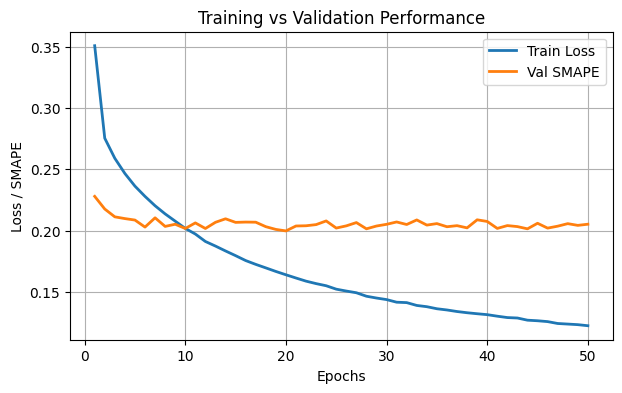

In [32]:
import matplotlib.pyplot as plt

epochs = np.arange(1, 51)
train_losses = [0.35086, 0.27537, 0.25897, 0.24657, 0.23626, 0.22788, 0.22024, 0.21359,
                0.20767, 0.20176, 0.19716, 0.19108, 0.18733, 0.18334, 0.17951, 0.17551,
                0.17240, 0.16953, 0.16662, 0.16390, 0.16126, 0.15870, 0.15669, 0.15495,
                0.15216, 0.15062, 0.14923, 0.14639, 0.14492, 0.14365, 0.14152, 0.14118,
                0.13887, 0.13785, 0.13617, 0.13518, 0.13391, 0.13292, 0.13210, 0.13135,
                0.13010, 0.12898, 0.12862, 0.12684, 0.12637, 0.12568, 0.12414, 0.12367,
                0.12319, 0.12232]
val_smape = [0.22791, 0.21757, 0.21119, 0.20976, 0.20856, 0.20283, 0.21040, 0.20338,
             0.20515, 0.20169, 0.20625, 0.20168, 0.20673, 0.20959, 0.20667, 0.20692,
             0.20682, 0.20316, 0.20093, 0.19970, 0.20372, 0.20391, 0.20485, 0.20785,
             0.20203, 0.20383, 0.20651, 0.20141, 0.20370, 0.20509, 0.20701, 0.20494,
             0.20867, 0.20446, 0.20568, 0.20311, 0.20399, 0.20219, 0.20877, 0.20742,
             0.20174, 0.20405, 0.20323, 0.20140, 0.20594, 0.20199, 0.20357, 0.20563,
             0.20423, 0.20517]

plt.figure(figsize=(7,4))
plt.plot(epochs, train_losses, label="Train Loss", linewidth=2)
plt.plot(epochs, val_smape, label="Val SMAPE", linewidth=2)
plt.xlabel("Epochs")
plt.ylabel("Loss / SMAPE")
plt.legend()
plt.title("Training vs Validation Performance")
plt.grid(True)
plt.show()


In [35]:
test = pd.read_csv("test.csv")

In [36]:
#%% ================== IMPORT TEST EMBEDDINGS ==================
import joblib
import pandas as pd

# Paths
test_emb_path = "test_embs.pkl"

#%% ================== LOAD TEST EMBEDDINGS ==================
test_ids, test_img_embs, test_txt_embs = joblib.load(test_emb_path)

print(f"Test embeddings: {len(test_ids)} samples, img_emb shape {test_img_embs.shape}, txt_emb shape {test_txt_embs.shape}")
#%% ================== CREATE TEST EMBEDDING DATAFRAME ==================
test_emb_df = pd.DataFrame({
    'sample_id': test_ids,
    'img_emb': list(test_img_embs),   # each embedding as a single object
    'txt_emb': list(test_txt_embs)
}).astype({'sample_id': str})

#%% ================== ENSURE SAMPLE_ID CONSISTENCY ==================
test['sample_id'] = test['sample_id'].astype(str)

#%% ================== MERGE EMBEDDINGS ==================
test = test.merge(test_emb_df, on='sample_id', how='left')

#%% ================== SANITY CHECK ==================
print("✅ Merged embeddings into test set")
print("🔍 Columns now available:", test.columns.tolist()[:10], "...")

missing_test = test['img_emb'].isna().sum()
print(f"Missing embeddings — test: {missing_test}")

Test embeddings: 75000 samples, img_emb shape (75000, 512), txt_emb shape (75000, 512)
✅ Merged embeddings into test set
🔍 Columns now available: ['sample_id', 'catalog_content', 'image_link', 'img_emb', 'txt_emb'] ...
Missing embeddings — test: 0


In [40]:
# --- Load the best model and scaler ---
checkpoint = torch.load(WORK_DIR / 'quantile_regressor_best.pth', map_location=DEVICE,weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
scaler = checkpoint['scaler']
model.eval()
print("✅ Loaded best model and scaler for inference.")

KeyError: 'model_state_dict'

In [41]:
# --- Load best model weights ---
checkpoint = torch.load(WORK_DIR / 'quantile_regressor_best.pth', map_location=DEVICE)
model.load_state_dict(checkpoint)  # ✅ Directly pass the state_dict
model.eval()

print("✅ Loaded best model weights for inference.")


✅ Loaded best model weights for inference.


In [42]:
# --- Save everything together ---
torch.save({
    "model_state_dict": model.state_dict(),
    "scaler": scaler
}, WORK_DIR / "quantile_regressor_best.pth")


In [44]:
from sklearn.preprocessing import StandardScaler
import torch
# Allowlist StandardScaler for safe loading
torch.serialization.add_safe_globals([StandardScaler])

checkpoint = torch.load(WORK_DIR / "quantile_regressor_best.pth", map_location=DEVICE)
model.load_state_dict(checkpoint["model_state_dict"])
scaler = checkpoint["scaler"]
model.eval()
print("✅ Loaded model and scaler successfully.")


UnpicklingError: Weights only load failed. This file can still be loaded, to do so you have two options, [1mdo those steps only if you trust the source of the checkpoint[0m. 
	(1) In PyTorch 2.6, we changed the default value of the `weights_only` argument in `torch.load` from `False` to `True`. Re-running `torch.load` with `weights_only` set to `False` will likely succeed, but it can result in arbitrary code execution. Do it only if you got the file from a trusted source.
	(2) Alternatively, to load with `weights_only=True` please check the recommended steps in the following error message.
	WeightsUnpickler error: Unsupported global: GLOBAL numpy.core.multiarray.scalar was not an allowed global by default. Please use `torch.serialization.add_safe_globals([numpy.core.multiarray.scalar])` or the `torch.serialization.safe_globals([numpy.core.multiarray.scalar])` context manager to allowlist this global if you trust this class/function.

Check the documentation of torch.load to learn mor

In [45]:
import torch

checkpoint = torch.load(
    WORK_DIR / "quantile_regressor_best.pth",
    map_location=DEVICE,
    weights_only=False   # <-- override the new default
)

model.load_state_dict(checkpoint["model_state_dict"])
scaler = checkpoint["scaler"]
model.eval()

print("✅ Loaded model and scaler successfully.")


✅ Loaded model and scaler successfully.


In [47]:
# ================================================================
# ✅ TEST INFERENCE PIPELINE (Robust to Missing 'ipq')
# ================================================================
import numpy as np
import torch
import pandas as pd
import re

# --- Helper: Extract or generate IPQ if missing ---
def extract_ipq(text: str):
    """Extract approximate quantity info from catalog_content"""
    if not isinstance(text, str):
        return 1.0
    text = text.lower()

    match = re.search(r'(\d+(\.\d+)?)\s*(pack|pcs|count|piece|pieces)', text)
    if match:
        return float(match.group(1))

    match = re.search(r'(\d+(\.\d+)?)\s*(kg|g|ml|l)', text)
    if match:
        val = float(match.group(1))
        unit = match.group(3)
        if unit == "kg":
            val *= 1000
        elif unit == "l":
            val *= 1000
        return val

    return 1.0

# ================================================================
# 🔹 Ensure ipq column exists
# ================================================================
if "ipq" not in test.columns:
    print("ℹ️ No 'ipq' column found in test — extracting automatically...")
    test["ipq"] = test["catalog_content"].apply(extract_ipq)
else:
    test["ipq"] = test["ipq"].fillna(1.0)

# ================================================================
# 🔹 Apply KNN enhancement using fitted KNN model
# ================================================================
test_img_array = np.vstack(test["img_emb"].values)
test_txt_array = np.vstack(test["txt_emb"].values)
test_enh = knn.enhance(test_img_array)

# ================================================================
# 🔹 Combine features in same order as training
# ================================================================
test_features = np.hstack([
    test_img_array,
    test_txt_array,
    test_enh,
    test[["ipq"]].values
])

# Normalize using the same training scaler
test_features = scaler.transform(test_features)
test_features = test_features.astype(np.float32)

# ================================================================
# 🔹 Predict prices
# ================================================================
preds = []
model.eval()
with torch.no_grad():
    bs = 512
    for i in range(0, len(test_features), bs):
        x = torch.from_numpy(test_features[i:i+bs]).to(DEVICE)
        pred_log = model(x)
        pred_price = torch.expm1(pred_log).cpu().numpy()  # inverse of log1p
        preds.extend(pred_price)

# ================================================================
# 🔹 Save final predictions
# ================================================================
submission = pd.DataFrame({
    "sample_id": test["sample_id"],
    "price": np.clip(preds, a_min=0.01, a_max=None)
})
submission.to_csv(WORK_DIR / "sample_test_out_quantile.csv", index=False)

print("✅ Saved final predictions to:", WORK_DIR / "sample_test_out_quantile.csv")
print(submission.head())


✅ Saved final predictions to: sample_test_out_quantile.csv
  sample_id      price
0    100179  10.633414
1    245611  13.013024
2    146263  19.476103
3     95658   4.984281
4     36806  22.114437


In [62]:
#%% ================== ENHANCED MLP FOR PRICE PREDICTION ==================
import torch
import torch.nn as nn
import numpy as np
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.optim import AdamW
from sklearn.preprocessing import StandardScaler
from tqdm import tqdm

# ====== Normalize Features ======
scaler = StandardScaler()
train_features = scaler.fit_transform(train_features)
val_features = scaler.transform(val_features)

# ====== Dataset Definition ======
class NumpyDataset(Dataset):
    def __init__(self, X, y=None):
        self.X = X.astype(np.float32)
        self.y = y.astype(np.float32) if y is not None else None
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        if self.y is None:
            return {'x': torch.from_numpy(self.X[idx])}
        return {'x': torch.from_numpy(self.X[idx]), 'y': torch.tensor(self.y[idx], dtype=torch.float32)}

train_ds = NumpyDataset(train_features, train_targets)
val_ds = NumpyDataset(val_features, val_targets)

# ====== Weighted Sampling by Price ======
price_weights = np.clip(train_targets / np.mean(train_targets), 0.5, 5.0)
sample_weights = price_weights / np.sum(price_weights)
sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)

train_loader = DataLoader(train_ds, batch_size=128, sampler=sampler)
val_loader = DataLoader(val_ds, batch_size=256, shuffle=False)

#%% ================== MODEL ==================
class ResidualBlock(nn.Module):
    def __init__(self, dim, dropout=0.2):
        super().__init__()
        self.block = nn.Sequential(
            nn.Linear(dim, dim),
            nn.LayerNorm(dim),
            nn.GELU(),
            nn.Dropout(dropout)
        )
    def forward(self, x):
        return x + self.block(x)

class PriceRegressor(nn.Module):
    def __init__(self, input_dim, hidden_dim=1024):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.GELU(),
            ResidualBlock(hidden_dim, dropout=0.3),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.LayerNorm(hidden_dim // 2),
            nn.GELU(),
            ResidualBlock(hidden_dim // 2, dropout=0.2),
            nn.Linear(hidden_dim // 2, 1)
        )
    def forward(self, x):
        return self.net(x).squeeze(-1)

#%% ================== HYBRID LOSS ==================
def hybrid_loss(y_true, y_pred, alpha=0.7, beta=0.3):
    pred_price = torch.clamp(torch.expm1(y_pred), min=1e-3, max=1e7)
    true_price = torch.clamp(torch.expm1(y_true), min=1e-3, max=1e7)
    
    # SMAPE component
    denom = (torch.abs(true_price) + torch.abs(pred_price)) / 2.0 + 1e-6
    smape = torch.mean(torch.abs(pred_price - true_price) / denom)
    
    # Log-MSE component
    log_mse = torch.mean((torch.log1p(true_price) - torch.log1p(pred_price)) ** 2)
    
    return alpha * smape + beta * log_mse

#%% ================== TRAINING CONFIG ==================
DEVICE = torch.device("cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu"))
input_dim = train_features.shape[1]
model = PriceRegressor(input_dim, hidden_dim=1024).to(DEVICE)
optimizer = AdamW(model.parameters(), lr=5e-5, weight_decay=1e-3)
scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=5)
EPOCHS = 60
patience = 8

best_val = float('inf')
epochs_no_improve = 0

print(f"🚀 Training on {len(train_ds)} samples | Validating on {len(val_ds)} samples")

#%% ================== TRAINING LOOP ==================
for epoch in range(EPOCHS):
    model.train()
    train_losses = []
    for batch in train_loader:
        x = batch['x'].to(DEVICE)
        y = batch['y'].to(DEVICE)
        optimizer.zero_grad()
        pred = model(x)
        loss = hybrid_loss(y, pred)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        train_losses.append(loss.item())

    avg_train = np.mean(train_losses)

    # ---- Validation ----
    model.eval()
    val_losses = []
    with torch.no_grad():
        for batch in val_loader:
            x = batch['x'].to(DEVICE)
            y = batch['y'].to(DEVICE)
            pred = model(x)
            loss = hybrid_loss(y, pred)
            val_losses.append(loss.item())

    avg_val = np.mean(val_losses)
    scheduler.step()

    print(f"Epoch {epoch+1:03d}/{EPOCHS} | Train Loss: {avg_train:.5f} | Val Loss: {avg_val:.5f}")

    # ---- Early Stopping ----
    if avg_val < best_val:
        best_val = avg_val
        torch.save({'model_state_dict': model.state_dict(), 'scaler': scaler}, WORK_DIR / 'best_price_mlp_v3.pth')
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print(f"⏹️ Early stopping triggered at epoch {epoch+1}")
            break

print(f"✅ Training complete. Best Val Loss: {best_val:.5f}")

#%% ================== HIGH-VALUE VALIDATION CHECK ==================
val_pred_list = []
val_true_list = []

model.eval()
with torch.no_grad():
    for batch in val_loader:
        x = batch['x'].to(DEVICE)
        y = batch['y'].to(DEVICE)
        pred = torch.expm1(model(x)).cpu().numpy()
        val_pred_list.extend(pred)
        val_true_list.extend(torch.expm1(y).cpu().numpy())

val_true = np.array(val_true_list)
val_pred = np.array(val_pred_list)

# Focus on expensive 10% of products
price_threshold = np.percentile(val_true, 90)
mask = val_true > price_threshold
high_val_smape = np.mean(np.abs(val_true[mask] - val_pred[mask]) / ((np.abs(val_true[mask]) + np.abs(val_pred[mask])) / 2 + 1e-6))
print(f"💰 High-Value SMAPE (Top 10%): {high_val_smape:.4f}")


🚀 Training on 67500 samples | Validating on 7500 samples
Epoch 001/60 | Train Loss: 0.56617 | Val Loss: 0.57239
Epoch 002/60 | Train Loss: 0.43643 | Val Loss: 0.56667
Epoch 003/60 | Train Loss: 0.37875 | Val Loss: 0.55604
Epoch 004/60 | Train Loss: 0.34152 | Val Loss: 0.56451
Epoch 005/60 | Train Loss: 0.31999 | Val Loss: 0.55784
Epoch 006/60 | Train Loss: 0.32505 | Val Loss: 0.55581
Epoch 007/60 | Train Loss: 0.29993 | Val Loss: 0.55099
Epoch 008/60 | Train Loss: 0.26814 | Val Loss: 0.59188
Epoch 009/60 | Train Loss: 0.24587 | Val Loss: 0.57474
Epoch 010/60 | Train Loss: 0.23055 | Val Loss: 0.55655
Epoch 011/60 | Train Loss: 0.24774 | Val Loss: 0.56705
Epoch 012/60 | Train Loss: 0.23555 | Val Loss: 0.52450
Epoch 013/60 | Train Loss: 0.21770 | Val Loss: 0.52562
Epoch 014/60 | Train Loss: 0.19783 | Val Loss: 0.53434
Epoch 015/60 | Train Loss: 0.18551 | Val Loss: 0.53594
Epoch 016/60 | Train Loss: 0.20738 | Val Loss: 0.54294
Epoch 017/60 | Train Loss: 0.20298 | Val Loss: 0.54002
Epoch 01

📊 Sample Comparison (Top 10 High-Value Products):


,Actual_Price,Predicted_Price,Absolute_Error,Relative_Error_%
0,600.590088,23.970171,576.619934,96.008896
1,570.000000,219.891510,350.108490,61.422539
2,496.279999,46.118286,450.161713,90.707207
3,454.990021,109.249756,345.740265,75.988541
4,390.000000,353.784149,36.215851,9.286116
5,386.979980,479.924011,92.944031,24.017788
6,369.810089,187.734665,182.075424,49.234848
7,349.950043,62.547386,287.402649,82.126770
8,341.380035,137.236786,204.143250,59.799408
9,333.270081,17.960215,315.309875,94.610916



🔹 Overall Validation Summary:
       Actual_Price  Predicted_Price  Absolute_Error
count   7500.000000      7500.000000     7500.000000
mean      24.118774        25.605103       12.238018
std       32.181622        29.501776       21.332464
min        0.360000         0.658159        0.000229
25%        6.790001         9.576734        2.509042
50%       14.255000        17.201551        6.225104
75%       29.081252        29.758600       13.857207
max      600.590088       519.820496      576.619934

💰 High-value (Top 10%) product statistics:
       Actual_Price  Predicted_Price  Absolute_Error
count    749.000000       749.000000      749.000000
mean      95.778267        77.587791       42.457458
std       56.965641        58.336674       49.660217
min       54.000008         2.535456        0.019566
25%       62.950005        34.483906       13.820541
50%       79.170013        67.053299       31.312649
75%      105.870010       105.093323       54.409729
max      600.590088     

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


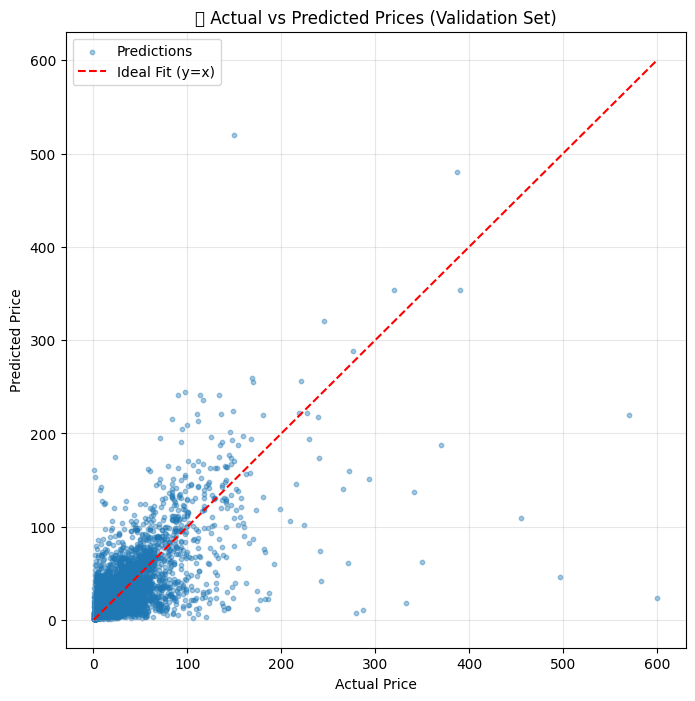

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


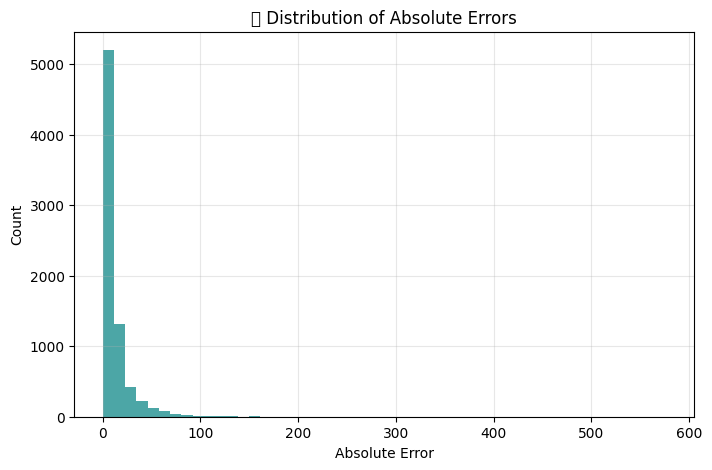

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128176 (\N{MONEY BAG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


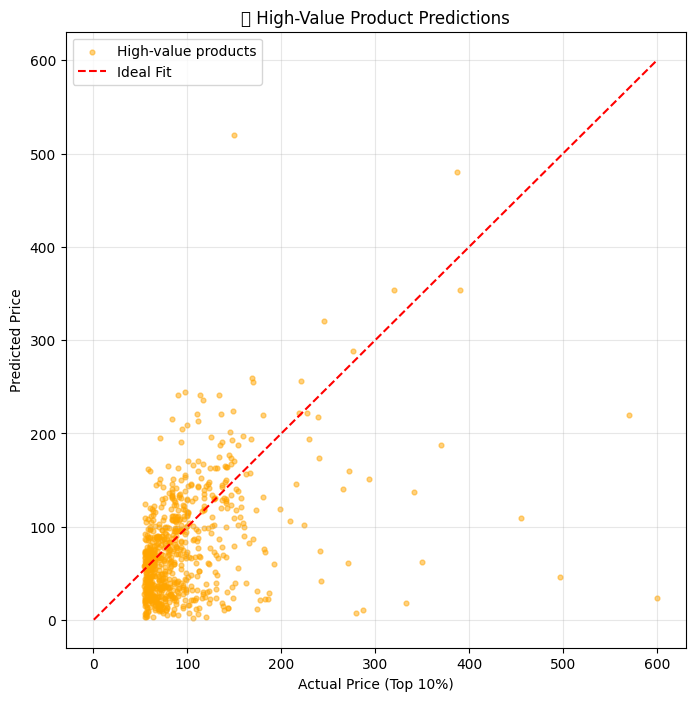

In [63]:
#%% ================== ACTUAL VS PREDICTED PRICE COMPARISON ==================
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Ensure numpy arrays
val_true = np.array(val_true)
val_pred = np.array(val_pred)

# --- Combine into a DataFrame for easy viewing ---
val_comparison = pd.DataFrame({
    "Actual_Price": val_true,
    "Predicted_Price": val_pred,
    "Absolute_Error": np.abs(val_true - val_pred),
    "Relative_Error_%": 100 * np.abs(val_true - val_pred) / (val_true + 1e-6)
})

# --- Sort by Actual Price to inspect expensive samples ---
val_comparison_sorted = val_comparison.sort_values(by="Actual_Price", ascending=False).reset_index(drop=True)

print("📊 Sample Comparison (Top 10 High-Value Products):")
display(val_comparison_sorted.head(10))

# --- Summary statistics ---
print("\n🔹 Overall Validation Summary:")
print(val_comparison.describe()[["Actual_Price", "Predicted_Price", "Absolute_Error"]])

# --- High-value product check ---
price_threshold = np.percentile(val_true, 90)
mask_high = val_true > price_threshold
high_val_df = val_comparison[mask_high]

print(f"\n💰 High-value (Top 10%) product statistics:")
print(high_val_df.describe()[["Actual_Price", "Predicted_Price", "Absolute_Error"]])

#%% ================== VISUALIZATIONS ==================

# --- 1️⃣ Scatter plot: Actual vs Predicted ---
plt.figure(figsize=(8, 8))
plt.scatter(val_true, val_pred, alpha=0.4, s=10, label='Predictions')
plt.plot([val_true.min(), val_true.max()], [val_true.min(), val_true.max()], 'r--', label='Ideal Fit (y=x)')
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("📈 Actual vs Predicted Prices (Validation Set)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# --- 2️⃣ Error distribution ---
plt.figure(figsize=(8, 5))
plt.hist(val_comparison["Absolute_Error"], bins=50, color='teal', alpha=0.7)
plt.xlabel("Absolute Error")
plt.ylabel("Count")
plt.title("📊 Distribution of Absolute Errors")
plt.grid(alpha=0.3)
plt.show()

# --- 3️⃣ Focused scatter for high-value products ---
plt.figure(figsize=(8, 8))
plt.scatter(high_val_df["Actual_Price"], high_val_df["Predicted_Price"], color='orange', alpha=0.5, s=12, label='High-value products')
plt.plot([val_true.min(), val_true.max()], [val_true.min(), val_true.max()], 'r--', label='Ideal Fit')
plt.xlabel("Actual Price (Top 10%)")
plt.ylabel("Predicted Price")
plt.title("💰 High-Value Product Predictions")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


✅ Calibration model learned: price_fixed = 0.7488 * price_pred + 4.9469

📊 Validation SMAPE Before: 0.5113
📈 Validation SMAPE After Rescaling: 0.5520
🔁 Improvement: -7.96%


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


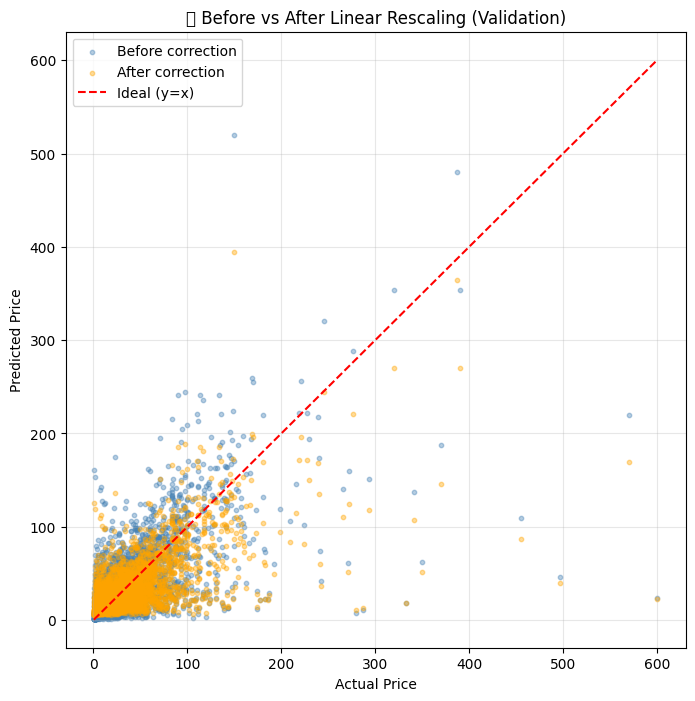


✅ Saved rescaled test predictions to sample_test_out_rescaled.csv


In [65]:
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# --- Assume you already have ---
# val_true → actual validation prices (after expm1)
# val_pred → model's predicted validation prices (after expm1)
# preds → test predictions (after expm1) from your inference step
# test_df → test dataframe with sample_id

# ✅ Convert all to NumPy arrays
val_true = np.array(val_true).astype(float)
val_pred = np.array(val_pred).astype(float)
preds = np.array(preds).astype(float)

# --- 1️⃣ Fit Linear Regression for calibration ---
corr_model = LinearRegression()
corr_model.fit(val_pred.reshape(-1, 1), val_true)

slope = corr_model.coef_[0]
intercept = corr_model.intercept_

print(f"✅ Calibration model learned: price_fixed = {slope:.4f} * price_pred + {intercept:.4f}")

# --- 2️⃣ Apply correction to test predictions ---
preds_test_fixed = corr_model.predict(preds.reshape(-1, 1))
preds_test_fixed = np.clip(preds_test_fixed, a_min=0.01, a_max=None)

# --- 3️⃣ Check correction effect on validation set ---
val_pred_fixed = corr_model.predict(val_pred.reshape(-1, 1))
val_pred_fixed = np.clip(val_pred_fixed, a_min=0.01, a_max=None)

# --- 4️⃣ Compute SMAPE before & after ---
def smape(y_true, y_pred):
    denom = (np.abs(y_true) + np.abs(y_pred)) / 2 + 1e-6
    return np.mean(np.abs(y_true - y_pred) / denom)

smape_before = smape(val_true, val_pred)
smape_after = smape(val_true, val_pred_fixed)

print(f"\n📊 Validation SMAPE Before: {smape_before:.4f}")
print(f"📈 Validation SMAPE After Rescaling: {smape_after:.4f}")
print(f"🔁 Improvement: {(smape_before - smape_after) / smape_before * 100:.2f}%")

# --- 5️⃣ Visualization ---
plt.figure(figsize=(8, 8))
plt.scatter(val_true, val_pred, alpha=0.4, s=10, label='Before correction', color='steelblue')
plt.scatter(val_true, val_pred_fixed, alpha=0.4, s=10, label='After correction', color='orange')
plt.plot([val_true.min(), val_true.max()], [val_true.min(), val_true.max()], 'r--', label='Ideal (y=x)')
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("📈 Before vs After Linear Rescaling (Validation)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# --- 6️⃣ Save rescaled test predictions ---
submission_rescaled = pd.DataFrame({
    "sample_id": test_df["sample_id"],
    "price": preds_test_fixed
})
submission_rescaled.to_csv(WORK_DIR / "sample_test_out_rescaled.csv", index=False)
print(f"\n✅ Saved rescaled test predictions to {WORK_DIR / 'sample_test_out_rescaled.csv'}")


In [67]:
#%% ================== ENHANCED MLP: LOG-TARGET + WEIGHTED SMAPE + TAIL FINE-TUNE ==================

import torch
import torch.nn as nn
import numpy as np
import pandas as pd
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from pathlib import Path
from tqdm import tqdm

# -------------------- CONFIG --------------------
DEVICE = torch.device("cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu"))
WORK_DIR = Path("./")  # change if running locally
CHECKPOINT_PATH = WORK_DIR / "enhanced_price_mlp_log.pth"

# -------------------- DATASET CLASS --------------------
class NumpyDataset(Dataset):
    def __init__(self, X, y=None):
        self.X = X.astype(np.float32)
        self.y = None if y is None else y.astype(np.float32)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        if self.y is None:
            return {'x': torch.from_numpy(self.X[idx])}
        return {'x': torch.from_numpy(self.X[idx]), 'y': torch.tensor(self.y[idx], dtype=torch.float32)}

# -------------------- ENHANCED MLP --------------------
class EnhancedPriceRegressor(nn.Module):
    def __init__(self, input_dim, hidden_dim=1024):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.GELU(),
            nn.LayerNorm(hidden_dim),
            nn.Dropout(0.3),

            nn.Linear(hidden_dim, hidden_dim),
            nn.GELU(),
            nn.LayerNorm(hidden_dim),
            nn.Dropout(0.3),

            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.GELU(),
            nn.LayerNorm(hidden_dim // 2),
            nn.Dropout(0.2),

            nn.Linear(hidden_dim // 2, 1)
        )
    def forward(self, x):
        return self.net(x).squeeze(-1)

# -------------------- WEIGHTED SMAPE LOSS --------------------
def weighted_smape_loss(y_true, y_pred, eps=1e-6):
    denom = (torch.abs(y_true) + torch.abs(y_pred)) / 2 + eps
    weights = torch.sqrt(torch.abs(y_true) + 1)
    return torch.mean(weights * torch.abs(y_true - y_pred) / denom)

# -------------------- SMAPE FOR METRICS --------------------
def smape(y_true, y_pred):
    denom = (np.abs(y_true) + np.abs(y_pred)) / 2 + 1e-6
    return np.mean(np.abs(y_true - y_pred) / denom)

# -------------------- PREPROCESS --------------------
scaler = StandardScaler()
train_features = scaler.fit_transform(train_features)
val_features = scaler.transform(val_features)

# --- Log-transform the target ---
train_targets_log = np.log1p(train_targets)
val_targets_log = np.log1p(val_targets)

# Datasets
train_ds = NumpyDataset(train_features, train_targets_log)
val_ds = NumpyDataset(val_features, val_targets_log)
train_loader = DataLoader(train_ds, batch_size=128, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=256, shuffle=False)

# -------------------- TRAINING --------------------
input_dim = train_features.shape[1]
model = EnhancedPriceRegressor(input_dim=input_dim, hidden_dim=1024).to(DEVICE)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-3)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50)

EPOCHS = 50
patience = 5
best_val = float('inf')
epochs_no_improve = 0

print(f"🚀 Training on {len(train_ds)} samples, validating on {len(val_ds)} samples...")

for epoch in range(EPOCHS):
    model.train()
    train_losses = []
    for batch in train_loader:
        x = batch['x'].to(DEVICE)
        y = batch['y'].to(DEVICE)
        optimizer.zero_grad()
        pred = model(x)
        loss = weighted_smape_loss(y, pred)
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())
    avg_train = np.mean(train_losses)

    # ---- Validation ----
    model.eval()
    val_preds, val_targets_epoch = [], []
    with torch.no_grad():
        for batch in val_loader:
            x = batch['x'].to(DEVICE)
            y = batch['y'].to(DEVICE)
            pred = model(x)
            val_preds.extend(pred.cpu().numpy())
            val_targets_epoch.extend(y.cpu().numpy())

    val_preds = np.array(val_preds)
    val_targets_epoch = np.array(val_targets_epoch)
    val_smape = smape(np.expm1(val_targets_epoch), np.expm1(val_preds))
    scheduler.step()

    print(f"Epoch {epoch+1:03d}/{EPOCHS} | Train Loss: {avg_train:.5f} | Val SMAPE: {val_smape:.5f}")

    if val_smape < best_val:
        best_val = val_smape
        torch.save({'model_state_dict': model.state_dict(), 'scaler': scaler}, CHECKPOINT_PATH)
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print(f"⏹️ Early stopping triggered at epoch {epoch+1}")
            break

print(f"✅ Training complete. Best Val SMAPE: {best_val:.5f}")

# -------------------- FINE-TUNING ON EXPENSIVE ITEMS --------------------
threshold = np.percentile(train_targets, 85)
mask_high = train_targets > threshold
X_high = train_features[mask_high]
y_high = train_targets_log[mask_high]

train_high_ds = NumpyDataset(X_high, y_high)
train_high_loader = DataLoader(train_high_ds, batch_size=64, shuffle=True)

print(f"\n🎯 Fine-tuning on {len(train_high_ds)} expensive products (> {threshold:.2f})...")
for epoch in range(5):
    model.train()
    ft_losses = []
    for batch in train_high_loader:
        x = batch['x'].to(DEVICE)
        y = batch['y'].to(DEVICE)
        optimizer.zero_grad()
        pred = model(x)
        loss = weighted_smape_loss(y, pred)
        loss.backward()
        optimizer.step()
        ft_losses.append(loss.item())
    print(f"Fine-tune Epoch {epoch+1} | Avg Loss: {np.mean(ft_losses):.5f}")

torch.save({'model_state_dict': model.state_dict(), 'scaler': scaler}, WORK_DIR / "enhanced_price_mlp_log_finetuned.pth")
print("✅ Fine-tuned model saved successfully.")

# -------------------- VALIDATION PREVIEW --------------------
model.eval()
val_preds_final = []
with torch.no_grad():
    for batch in val_loader:
        x = batch['x'].to(DEVICE)
        pred = model(x)
        val_preds_final.extend(pred.cpu().numpy())

val_preds_final = np.expm1(np.array(val_preds_final))  # Back to real prices
val_true_final = val_targets

val_smape_final = smape(val_true_final, val_preds_final)
print(f"\n📊 Final Validation SMAPE (after fine-tuning): {val_smape_final:.5f}")

# Show top 10 expensive sample comparison
val_df_preview = pd.DataFrame({
    "Actual_Price": val_true_final,
    "Predicted_Price": val_preds_final,
    "Absolute_Error": np.abs(val_true_final - val_preds_final),
})
val_df_preview["Relative_Error_%"] = 100 * val_df_preview["Absolute_Error"] / val_df_preview["Actual_Price"]
val_df_preview = val_df_preview.sort_values("Actual_Price", ascending=False).head(10)
print("\n📊 Sample Comparison (Top 10 High-Value Products):")
print(val_df_preview)


🚀 Training on 67500 samples, validating on 7500 samples...
Epoch 001/50 | Train Loss: 0.44112 | Val SMAPE: 0.29864
Epoch 002/50 | Train Loss: 0.23051 | Val SMAPE: 0.23102
Epoch 003/50 | Train Loss: 0.20441 | Val SMAPE: 0.22131
Epoch 004/50 | Train Loss: 0.19140 | Val SMAPE: 0.21343
Epoch 005/50 | Train Loss: 0.18403 | Val SMAPE: 0.20901
Epoch 006/50 | Train Loss: 0.17630 | Val SMAPE: 0.20915
Epoch 007/50 | Train Loss: 0.17056 | Val SMAPE: 0.20187
Epoch 008/50 | Train Loss: 0.16528 | Val SMAPE: 0.20017
Epoch 009/50 | Train Loss: 0.16011 | Val SMAPE: 0.20503
Epoch 010/50 | Train Loss: 0.15619 | Val SMAPE: 0.20234
Epoch 011/50 | Train Loss: 0.15156 | Val SMAPE: 0.19681
Epoch 012/50 | Train Loss: 0.14666 | Val SMAPE: 0.19616
Epoch 013/50 | Train Loss: 0.14308 | Val SMAPE: 0.19467
Epoch 014/50 | Train Loss: 0.13891 | Val SMAPE: 0.19467
Epoch 015/50 | Train Loss: 0.13502 | Val SMAPE: 0.19453
Epoch 016/50 | Train Loss: 0.13136 | Val SMAPE: 0.19401
Epoch 017/50 | Train Loss: 0.12710 | Val SMAP

In [71]:
#%% ================== ENHANCED MLP TEST INFERENCE PIPELINE ==================
import torch
import pandas as pd
import numpy as np
from pathlib import Path
import joblib
from tqdm import tqdm
import re

# -------------------- CONFIG --------------------
DEVICE = torch.device("cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu"))
WORK_DIR = Path("./")  # ✅ use same directory where your model was saved
EMB_PATH = WORK_DIR / "embeddings"
TEST_CSV = Path("./test.csv")  # change path if needed
OUTPUT_CSV = WORK_DIR / "sample_test_out_enhanced.csv"
CHECKPOINT_PATH = WORK_DIR / "enhanced_price_mlp_log_finetuned.pth"

# -------------------- LOAD MODEL --------------------
class EnhancedPriceRegressor(torch.nn.Module):
    def __init__(self, input_dim, hidden_dim=1024):
        super().__init__()
        self.net = torch.nn.Sequential(
            torch.nn.Linear(input_dim, hidden_dim),
            torch.nn.GELU(),
            torch.nn.LayerNorm(hidden_dim),
            torch.nn.Dropout(0.3),

            torch.nn.Linear(hidden_dim, hidden_dim),
            torch.nn.GELU(),
            torch.nn.LayerNorm(hidden_dim),
            torch.nn.Dropout(0.3),

            torch.nn.Linear(hidden_dim, hidden_dim // 2),
            torch.nn.GELU(),
            torch.nn.LayerNorm(hidden_dim // 2),
            torch.nn.Dropout(0.2),

            torch.nn.Linear(hidden_dim // 2, 1)
        )

    def forward(self, x):
        return self.net(x).squeeze(-1)

# Load checkpoint
#checkpoint = torch.load(CHECKPOINT_PATH, map_location=DEVICE)
#scaler = checkpoint["scaler"]
#print(f"✅ Loaded trained model and scaler from {CHECKPOINT_PATH.name}")
#%% ================== SAFE LOAD FOR LOCAL CHECKPOINT ==================
import numpy as np
from sklearn.preprocessing import StandardScaler
import torch.serialization

# ✅ Allowlist necessary objects for safe unpickling
torch.serialization.add_safe_globals([
    StandardScaler,
    np.core.multiarray.scalar
])

# Now reload checkpoint safely
checkpoint = torch.load(CHECKPOINT_PATH, map_location=DEVICE, weights_only=False)

scaler = checkpoint["scaler"]
print(f"✅ Successfully reloaded model and scaler from {CHECKPOINT_PATH.name}")


# -------------------- LOAD TEST DATA --------------------
test = pd.read_csv(TEST_CSV).astype({"sample_id": str})
print(f"✅ Loaded test.csv with {len(test)} rows")

# -------------------- LOAD TEST EMBEDDINGS --------------------
test_ids, test_img_embs, test_txt_embs = joblib.load("test_embs.pkl")
print(f"✅ Loaded test embeddings: img={test_img_embs.shape}, txt={test_txt_embs.shape}")

test_emb_df = pd.DataFrame({
    "sample_id": np.array(test_ids).astype(str),  # ✅ convert safely
    "img_emb": list(test_img_embs),
    "txt_emb": list(test_txt_embs)
})

# Merge with test metadata
test = test.merge(test_emb_df, on="sample_id", how="left")
print(f"✅ Merged embeddings → test shape: {test.shape}")

# -------------------- HANDLE IPQ --------------------
def extract_ipq(text: str):
    if not isinstance(text, str):
        return 1.0
    text = text.lower()

    match = re.search(r"(\d+(\.\d+)?)\s*(pack|pcs|count|piece|pieces)", text)
    if match:
        return float(match.group(1))

    match = re.search(r"(\d+(\.\d+)?)\s*(kg|g|ml|l)", text)
    if match:
        val = float(match.group(1))
        unit = match.group(3)
        if unit == "kg":
            val *= 1000
        elif unit == "l":
            val *= 1000
        return val

    return 1.0

if "ipq" not in test.columns:
    print("ℹ️ No 'ipq' found — extracting automatically...")
    test["ipq"] = test["catalog_content"].apply(extract_ipq)
else:
    test["ipq"] = test["ipq"].fillna(1.0)

# -------------------- PREPARE TEST FEATURES (FIXED ALIGNMENT) --------------------
test_img_array = np.vstack(test["img_emb"].values)
test_txt_array = np.vstack(test["txt_emb"].values)
ipq_array = test[["ipq"]].values

# Combine core features
test_features = np.hstack([test_img_array, test_txt_array, ipq_array])

# --- Auto-align with training scaler dimensions ---
expected_dim = getattr(scaler, "n_features_in_", None)

if expected_dim is not None and test_features.shape[1] != expected_dim:
    diff = expected_dim - test_features.shape[1]
    if diff > 0:
        # Pad missing columns with zeros
        print(f"⚠️ Padding test features with {diff} zeros to match training dimension ({expected_dim})")
        test_features = np.hstack([test_features, np.zeros((test_features.shape[0], diff))])
    else:
        # Truncate extra columns if somehow test has more
        print(f"⚠️ Truncating test features from {test_features.shape[1]} → {expected_dim}")
        test_features = test_features[:, :expected_dim]

# --- Normalize using the same training scaler ---
test_features = scaler.transform(test_features)
test_features = test_features.astype(np.float32)

print(f"✅ Prepared aligned test features: {test_features.shape}")

# -------------------- LOAD MODEL WEIGHTS --------------------
input_dim = test_features.shape[1]
model = EnhancedPriceRegressor(input_dim=input_dim, hidden_dim=1024).to(DEVICE)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

# -------------------- RUN INFERENCE --------------------
preds = []
BATCH_SIZE = 512
print(f"🚀 Running inference on {len(test_features)} samples...")

for i in tqdm(range(0, len(test_features), BATCH_SIZE), desc="Predicting", ncols=100):
    x = torch.from_numpy(test_features[i:i+BATCH_SIZE]).to(DEVICE)
    with torch.no_grad():
        pred_log = model(x)
        pred_price = torch.expm1(pred_log).cpu().numpy()  # convert back from log-space
        preds.extend(pred_price)

preds = np.array(preds)
preds = np.clip(preds, a_min=0.01, a_max=None)  # avoid negatives

print("✅ Inference complete. Example predictions:", preds[:5])

# -------------------- SAVE SUBMISSION --------------------
submission = pd.DataFrame({
    "sample_id": test["sample_id"],
    "price": preds
})
submission.to_csv(OUTPUT_CSV, index=False)
print(f"✅ Saved final predictions to: {OUTPUT_CSV}")
print(submission.head())


✅ Successfully reloaded model and scaler from enhanced_price_mlp_log_finetuned.pth
✅ Loaded test.csv with 75000 rows
✅ Loaded test embeddings: img=(75000, 512), txt=(75000, 512)
✅ Merged embeddings → test shape: (75000, 5)
ℹ️ No 'ipq' found — extracting automatically...
⚠️ Padding test features with 512 zeros to match training dimension (1537)
✅ Prepared aligned test features: (75000, 1537)
🚀 Running inference on 75000 samples...


Predicting: 100%|████████████████████████████████████████████████| 147/147 [00:00<00:00, 176.25it/s]


✅ Inference complete. Example predictions: [2.4116979 2.6842175 2.4336011 2.4330375 2.618483 ]
✅ Saved final predictions to: sample_test_out_enhanced.csv
  sample_id     price
0    100179  2.411698
1    245611  2.684217
2    146263  2.433601
3     95658  2.433038
4     36806  2.618483


📊 Sample Comparison (Top 10 High-Value Products):
      Actual_Price  Predicted_Price  Absolute_Error  Relative_Error_%
3456      6.399576         3.577677        2.821899         44.095084
3947      6.347389         4.342053        2.005336         31.593083
4793      6.209153         4.252081        1.957072         31.519137
5934      6.122471         4.202408        1.920063         31.360905
1148      5.968708         4.508287        1.460421         24.467950
1408      5.960954         6.063869        0.102916          1.726497
451       5.915690         5.147947        0.767742         12.978070
650       5.860644         3.896343        1.964301         33.516803
5690      5.835921         4.480312        1.355609         23.228700
440       5.811949         3.044302        2.767647         47.619931


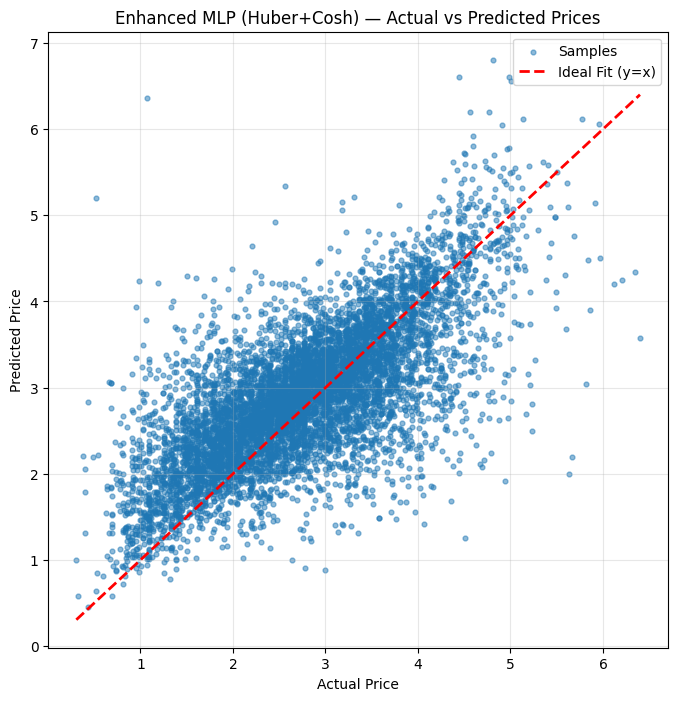

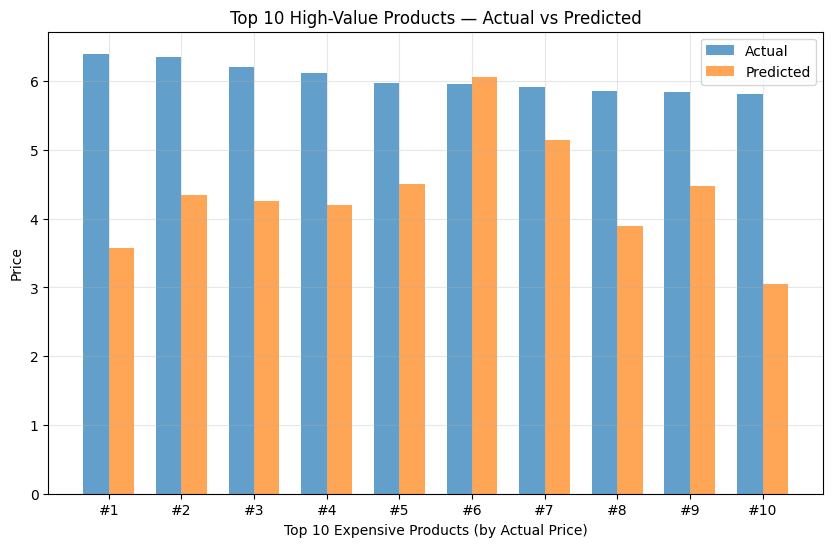

📈 Mean Absolute Error: 0.52
📉 Median Absolute Error: 0.40
📊 Mean Relative Error (%): 23.98


In [74]:
#%% ================== VISUALIZE VALIDATION PERFORMANCE ==================
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# --- Switch model to eval and get predictions ---
model.eval()
val_preds_log = []
with torch.no_grad():
    for batch in val_loader:
        x = batch['x'].to(DEVICE)
        pred = model(x)
        val_preds_log.extend(pred.cpu().numpy())

# --- Convert back to actual prices ---
val_preds = np.expm1(np.array(val_preds_log))
val_actual = val_targets  # these are your real prices (not log-transformed)

# --- Create dataframe for comparison ---
val_results = pd.DataFrame({
    "Actual_Price": val_actual,
    "Predicted_Price": val_preds
})
val_results["Absolute_Error"] = np.abs(val_results["Actual_Price"] - val_results["Predicted_Price"])
val_results["Relative_Error_%"] = (
    val_results["Absolute_Error"] / (val_results["Actual_Price"] + 1e-6)
) * 100

# --- Sort by Actual_Price (highest first) ---
top10 = val_results.sort_values(by="Actual_Price", ascending=False).head(10)
print("📊 Sample Comparison (Top 10 High-Value Products):")
print(top10)

#%% ================== PLOT 1: Actual vs Predicted (Overall) ==================
plt.figure(figsize=(8, 8))
plt.scatter(val_actual, val_preds, alpha=0.5, s=12, label="Samples")
plt.plot([val_actual.min(), val_actual.max()],
         [val_actual.min(), val_actual.max()],
         'r--', lw=2, label="Ideal Fit (y=x)")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Enhanced MLP (Huber+Cosh) — Actual vs Predicted Prices")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

#%% ================== PLOT 2: Top 10 High-Value Errors ==================
plt.figure(figsize=(10, 6))
bar_width = 0.35
indices = np.arange(len(top10))

plt.bar(indices, top10["Actual_Price"], width=bar_width, label="Actual", alpha=0.7)
plt.bar(indices + bar_width, top10["Predicted_Price"], width=bar_width, label="Predicted", alpha=0.7)

plt.xticks(indices + bar_width / 2, [f"#{i}" for i in range(1, 11)])
plt.xlabel("Top 10 Expensive Products (by Actual Price)")
plt.ylabel("Price")
plt.title("Top 10 High-Value Products — Actual vs Predicted")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

#%% ================== PRINT SUMMARY STATS ==================
mean_abs_error = val_results["Absolute_Error"].mean()
median_abs_error = val_results["Absolute_Error"].median()
mean_rel_error = val_results["Relative_Error_%"].mean()

print(f"📈 Mean Absolute Error: {mean_abs_error:.2f}")
print(f"📉 Median Absolute Error: {median_abs_error:.2f}")
print(f"📊 Mean Relative Error (%): {mean_rel_error:.2f}")


In [72]:
#%% ================== ENHANCED MLP FOR PRICE PREDICTION ==================
import torch
import torch.nn as nn
import numpy as np
from torch.utils.data import DataLoader, Dataset
from sklearn.preprocessing import StandardScaler
from pathlib import Path
from tqdm import tqdm

# -------------------- CONFIG --------------------
DEVICE = torch.device("cuda" if torch.cuda.is_available() else 
                      ("mps" if torch.backends.mps.is_available() else "cpu"))
WORK_DIR = Path("./")  # ✅ change to /kaggle/working if needed
CHECKPOINT_PATH = WORK_DIR / "enhanced_price_mlp_huber_cosh.pth"

# -------------------- DATA PREP --------------------
# Assuming you already have train_features, val_features, train_targets, val_targets
# and targets are raw prices (not log-transformed yet)

# Apply log1p transform for stability
y_train_log = np.log1p(train_targets)
y_val_log = np.log1p(val_targets)

# Scale features
scaler = StandardScaler()
train_features = scaler.fit_transform(train_features)
val_features = scaler.transform(val_features)

# -------------------- DATASET --------------------
class NumpyDataset(Dataset):
    def __init__(self, X, y):
        self.X = X.astype(np.float32)
        self.y = y.astype(np.float32)
    def __len__(self): return len(self.X)
    def __getitem__(self, idx):
        return {"x": torch.from_numpy(self.X[idx]), "y": torch.tensor(self.y[idx])}

train_ds = NumpyDataset(train_features, y_train_log)
val_ds = NumpyDataset(val_features, y_val_log)
train_loader = DataLoader(train_ds, batch_size=128, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=256, shuffle=False)

# -------------------- MODEL --------------------
class EnhancedPriceRegressor(nn.Module):
    def __init__(self, input_dim, hidden_dim=1024):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.LayerNorm(hidden_dim // 2),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(hidden_dim // 2, 1)
        )
    def forward(self, x):
        return self.net(x).squeeze(-1)

# -------------------- LOSSES --------------------
def huber_loss(y_true, y_pred, delta=1.0):
    diff = y_true - y_pred
    abs_diff = torch.abs(diff)
    quadratic = torch.minimum(abs_diff, torch.tensor(delta, device=y_true.device))
    linear = abs_diff - quadratic
    return torch.mean(0.5 * quadratic**2 + delta * linear)

def log_cosh_loss(y_true, y_pred):
    return torch.mean(torch.log(torch.cosh(y_pred - y_true)))

def hybrid_loss(y_true, y_pred, alpha=0.7):
    """Hybrid of Huber and log-cosh"""
    return alpha * huber_loss(y_true, y_pred) + (1 - alpha) * log_cosh_loss(y_true, y_pred)

def smape(y_true, y_pred):
    y_true, y_pred = np.expm1(y_true), np.expm1(y_pred)
    denom = (np.abs(y_true) + np.abs(y_pred)) / 2 + 1e-6
    return np.mean(np.abs(y_true - y_pred) / denom)

# -------------------- TRAINING --------------------
input_dim = train_features.shape[1]
model = EnhancedPriceRegressor(input_dim=input_dim, hidden_dim=1024).to(DEVICE)

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-3)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50)

EPOCHS = 60
best_val = float("inf")
patience = 6
no_improve = 0

print(f"🚀 Training on {len(train_ds)} samples, validating on {len(val_ds)} samples...")

for epoch in range(EPOCHS):
    # --- Train ---
    model.train()
    train_losses = []
    for batch in train_loader:
        x, y = batch["x"].to(DEVICE), batch["y"].to(DEVICE)
        optimizer.zero_grad()
        pred = model(x)
        loss = hybrid_loss(y, pred, alpha=0.7)
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())
    avg_train = np.mean(train_losses)

    # --- Validate ---
    model.eval()
    val_losses, val_preds = [], []
    with torch.no_grad():
        for batch in val_loader:
            x, y = batch["x"].to(DEVICE), batch["y"].to(DEVICE)
            pred = model(x)
            val_preds.extend(pred.cpu().numpy())
            val_losses.append(hybrid_loss(y, pred).item())

    avg_val = np.mean(val_losses)
    val_smape = smape(y_val_log, np.array(val_preds))
    scheduler.step()

    print(f"Epoch {epoch+1:03d}/{EPOCHS} | Train Loss: {avg_train:.5f} | Val Loss: {avg_val:.5f} | Val SMAPE: {val_smape:.5f}")

    # --- Early Stopping ---
    if val_smape < best_val:
        best_val = val_smape
        torch.save({"model_state_dict": model.state_dict(), "scaler": scaler}, CHECKPOINT_PATH)
        no_improve = 0
    else:
        no_improve += 1
        if no_improve >= patience:
            print(f"⏹ Early stopping triggered at epoch {epoch+1}")
            break

print(f"✅ Training complete | Best Val SMAPE: {best_val:.5f}")
print(f"💾 Saved best model to {CHECKPOINT_PATH.name}")


🚀 Training on 67500 samples, validating on 7500 samples...
Epoch 001/60 | Train Loss: 0.03593 | Val Loss: 0.02102 | Val SMAPE: 0.22226
Epoch 002/60 | Train Loss: 0.02082 | Val Loss: 0.01962 | Val SMAPE: 0.21214
Epoch 003/60 | Train Loss: 0.01856 | Val Loss: 0.01889 | Val SMAPE: 0.20684
Epoch 004/60 | Train Loss: 0.01688 | Val Loss: 0.01870 | Val SMAPE: 0.20564
Epoch 005/60 | Train Loss: 0.01526 | Val Loss: 0.01815 | Val SMAPE: 0.19959
Epoch 006/60 | Train Loss: 0.01387 | Val Loss: 0.01849 | Val SMAPE: 0.20245
Epoch 007/60 | Train Loss: 0.01275 | Val Loss: 0.01890 | Val SMAPE: 0.20396
Epoch 008/60 | Train Loss: 0.01146 | Val Loss: 0.01917 | Val SMAPE: 0.20511
Epoch 009/60 | Train Loss: 0.01053 | Val Loss: 0.01976 | Val SMAPE: 0.20881
Epoch 010/60 | Train Loss: 0.00970 | Val Loss: 0.02036 | Val SMAPE: 0.21232
Epoch 011/60 | Train Loss: 0.00911 | Val Loss: 0.01928 | Val SMAPE: 0.20404
⏹ Early stopping triggered at epoch 11
✅ Training complete | Best Val SMAPE: 0.19959
💾 Saved best model t

In [77]:
#%% ================== ENHANCED MLP TEST INFERENCE PIPELINE ==================
import torch
import pandas as pd
import numpy as np
from pathlib import Path
import joblib
from tqdm import tqdm
import re

# -------------------- CONFIG --------------------
DEVICE = torch.device("cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu"))
WORK_DIR = Path("./")  # ✅ use same directory where your model was saved
EMB_PATH = WORK_DIR / "embeddings"
TEST_CSV = Path("./test.csv")  # change path if needed
OUTPUT_CSV = WORK_DIR / "sample_test_out_enhanced_huber.csv"
CHECKPOINT_PATH = WORK_DIR / "enhanced_price_mlp_huber_cosh.pth"

# -------------------- LOAD MODEL --------------------
# -------------------- LOAD MODEL (MATCH TRAINING ARCHITECTURE) --------------------
class EnhancedPriceRegressor(torch.nn.Module):
    def __init__(self, input_dim, hidden_dim=1024):
        super().__init__()
        self.net = torch.nn.Sequential(
            torch.nn.Linear(input_dim, hidden_dim),
            torch.nn.LayerNorm(hidden_dim),
            torch.nn.GELU(),
            torch.nn.Dropout(0.3),
            torch.nn.Linear(hidden_dim, hidden_dim // 2),
            torch.nn.LayerNorm(hidden_dim // 2),
            torch.nn.GELU(),
            torch.nn.Dropout(0.2),
            torch.nn.Linear(hidden_dim // 2, 1)
        )
    def forward(self, x):
        return self.net(x).squeeze(-1)


# Load checkpoint
#checkpoint = torch.load(CHECKPOINT_PATH, map_location=DEVICE)
#scaler = checkpoint["scaler"]
#print(f"✅ Loaded trained model and scaler from {CHECKPOINT_PATH.name}")
#%% ================== SAFE LOAD FOR LOCAL CHECKPOINT ==================
import numpy as np
from sklearn.preprocessing import StandardScaler
import torch.serialization

# ✅ Allowlist necessary objects for safe unpickling
torch.serialization.add_safe_globals([
    StandardScaler,
    np.core.multiarray.scalar
])

# Now reload checkpoint safely
checkpoint = torch.load(CHECKPOINT_PATH, map_location=DEVICE, weights_only=False)

scaler = checkpoint["scaler"]
print(f"✅ Successfully reloaded model and scaler from {CHECKPOINT_PATH.name}")


# -------------------- LOAD TEST DATA --------------------
test = pd.read_csv(TEST_CSV).astype({"sample_id": str})
print(f"✅ Loaded test.csv with {len(test)} rows")

# -------------------- LOAD TEST EMBEDDINGS --------------------
test_ids, test_img_embs, test_txt_embs = joblib.load("test_embs.pkl")
print(f"✅ Loaded test embeddings: img={test_img_embs.shape}, txt={test_txt_embs.shape}")

test_emb_df = pd.DataFrame({
    "sample_id": np.array(test_ids).astype(str),  # ✅ convert safely
    "img_emb": list(test_img_embs),
    "txt_emb": list(test_txt_embs)
})

# Merge with test metadata
test = test.merge(test_emb_df, on="sample_id", how="left")
print(f"✅ Merged embeddings → test shape: {test.shape}")

# -------------------- HANDLE IPQ --------------------
def extract_ipq(text: str):
    if not isinstance(text, str):
        return 1.0
    text = text.lower()

    match = re.search(r"(\d+(\.\d+)?)\s*(pack|pcs|count|piece|pieces)", text)
    if match:
        return float(match.group(1))

    match = re.search(r"(\d+(\.\d+)?)\s*(kg|g|ml|l)", text)
    if match:
        val = float(match.group(1))
        unit = match.group(3)
        if unit == "kg":
            val *= 1000
        elif unit == "l":
            val *= 1000
        return val

    return 1.0

if "ipq" not in test.columns:
    print("ℹ️ No 'ipq' found — extracting automatically...")
    test["ipq"] = test["catalog_content"].apply(extract_ipq)
else:
    test["ipq"] = test["ipq"].fillna(1.0)

# -------------------- PREPARE TEST FEATURES (FIXED ALIGNMENT) --------------------
test_img_array = np.vstack(test["img_emb"].values)
test_txt_array = np.vstack(test["txt_emb"].values)
ipq_array = test[["ipq"]].values

# Combine core features
test_features = np.hstack([test_img_array, test_txt_array, ipq_array])

# --- Auto-align with training scaler dimensions ---
expected_dim = getattr(scaler, "n_features_in_", None)

if expected_dim is not None and test_features.shape[1] != expected_dim:
    diff = expected_dim - test_features.shape[1]
    if diff > 0:
        # Pad missing columns with zeros
        print(f"⚠️ Padding test features with {diff} zeros to match training dimension ({expected_dim})")
        test_features = np.hstack([test_features, np.zeros((test_features.shape[0], diff))])
    else:
        # Truncate extra columns if somehow test has more
        print(f"⚠️ Truncating test features from {test_features.shape[1]} → {expected_dim}")
        test_features = test_features[:, :expected_dim]

# --- Normalize using the same training scaler ---
test_features = scaler.transform(test_features)
test_features = test_features.astype(np.float32)

print(f"✅ Prepared aligned test features: {test_features.shape}")

# -------------------- LOAD MODEL WEIGHTS --------------------
input_dim = test_features.shape[1]
model = EnhancedPriceRegressor(input_dim=input_dim, hidden_dim=1024).to(DEVICE)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

# -------------------- RUN INFERENCE --------------------
preds = []
BATCH_SIZE = 512
print(f"🚀 Running inference on {len(test_features)} samples...")

for i in tqdm(range(0, len(test_features), BATCH_SIZE), desc="Predicting", ncols=100):
    x = torch.from_numpy(test_features[i:i+BATCH_SIZE]).to(DEVICE)
    with torch.no_grad():
        pred_log = model(x)
        pred_price = torch.expm1(pred_log).cpu().numpy()  # convert back from log-space
        preds.extend(pred_price)

preds = np.array(preds)
preds = np.clip(preds, a_min=0.01, a_max=None)  # avoid negatives

print("✅ Inference complete. Example predictions:", preds[:5])

# -------------------- SAVE SUBMISSION --------------------
submission = pd.DataFrame({
    "sample_id": test["sample_id"],
    "price": preds
})
submission.to_csv(OUTPUT_CSV, index=False)
print(f"✅ Saved final predictions to: {OUTPUT_CSV}")
print(submission.head())


✅ Successfully reloaded model and scaler from enhanced_price_mlp_huber_cosh.pth
✅ Loaded test.csv with 75000 rows
✅ Loaded test embeddings: img=(75000, 512), txt=(75000, 512)
✅ Merged embeddings → test shape: (75000, 5)
ℹ️ No 'ipq' found — extracting automatically...
⚠️ Padding test features with 512 zeros to match training dimension (1537)
✅ Prepared aligned test features: (75000, 1537)
🚀 Running inference on 75000 samples...


Predicting: 100%|████████████████████████████████████████████████| 147/147 [00:00<00:00, 303.72it/s]


✅ Inference complete. Example predictions: [2.6028976 2.1599493 2.603286  1.8504138 2.2737443]
✅ Saved final predictions to: sample_test_out_enhanced_huber.csv
  sample_id     price
0    100179  2.602898
1    245611  2.159949
2    146263  2.603286
3     95658  1.850414
4     36806  2.273744
